# Description du projet : Prédiction de la qualité du vin  

Ce projet vis à prédire la qualité du vin à partir de ses caractéristiques physico-chimiques. 
Dans un premier temps, les 7 catégories de qualité ont été utilisé sur les modèles de classification : Random Forest, AdaBoost, GradientBoost, KNN et XGBoost. L'objectif principal était de comparer les différents modèles.

Au vu des résultats, notamment sur le modèle Random Forest on aperçoit beaucoup de confusion entre classes voisines et des résultat très faible sur la majeure partie des classes malgré le changement d'hyperparamètres.

De ce fait, le dataset a été revue pour avoir in fine 3 catégories de qualité de vin : mauvais, médiocre, bon afin d'observer des résultats adéquats sur les modèles de classification suivant : Random Forest, KNN et XGBoost.

# Etape 1: Import et Analyse des données

### 📚 Import biblio + data

In [1]:
import pandas as pd
import numpy as np

#---- Préttraitement et pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#---- Modeles Classification 
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

#---- Evaluation des performances
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, mean_absolute_error
)
from sklearn.utils.class_weight import compute_class_weight

#---- Visualisation
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [11]:
# 1. CHARGEMENT DES DONNÉES
print("=== 📊  CHARGEMENT DES DONNÉES ===")

data_brute_wine = pd.read_csv('wine_data.csv', sep=',',header=0)
# data_brute_wine = data_brute_wine.rename(columns={'quality (score between 0 and 10)': 'quality'})
print("\nPremières lignes wine quality:")
print(data_brute_wine.head())
print(data_brute_wine.info())

# ce qu'on souhaite prédire c'est la qualité du vins (compris entre 3-low et 8-high) y_pred = quality


=== 📊  CHARGEMENT DES DONNÉES ===

Premières lignes wine quality:
   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0           11.6             0.580         0.66            2.20      0.074   
1           10.4             0.610         0.49            2.10      0.200   
2            7.4             1.185         0.00            4.25      0.097   
3           10.4             0.440         0.42            1.50      0.145   
4            8.3             1.020         0.02            3.40      0.084   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 10.0                  47.0  1.00080  3.25       0.57   
1                  5.0                  16.0  0.99940  3.16       0.63   
2                  5.0                  14.0  0.99660  3.63       0.54   
3                 34.0                  48.0  0.99832  3.38       0.86   
4                  6.0                  11.0  0.99892  3.48       0.49   

   alcohol  quality 

In [12]:
# 2. FEATURES / TARGET
X = data_brute_wine.drop(columns=['quality'])
y = data_brute_wine['quality']

X_df = X.copy()
duplicates = X_df[X_df.duplicated(keep=False)].head(10)
print("\nPREMIERS DUPLIQUÉS TROUVÉS:")
print(duplicates)

print("\nNOMBRE DE DOUBLONS:")
print(X_df.duplicated().sum())

print(f"\n% données uniques: {100 * (1 - X_df.duplicated().sum() / len(X_df)):.1f}%")


PREMIERS DUPLIQUÉS TROUVÉS:
    fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
31           13.3              1.39         0.80            41.9      0.200   
34           11.8              0.67         0.86            34.6      0.340   
35            6.8              0.69         0.89            44.8      0.140   
37           11.7              1.07         1.19            51.0      0.275   
41           10.8              1.05         1.43            48.0      0.302   
42           13.4              0.83         1.38            45.3      0.269   
44           13.3              0.98         0.47            59.3      0.370   
47           11.7              1.23         1.43            47.4      0.278   
48           14.4              1.24         0.97            49.4      0.356   
49           10.8              0.43         0.91            27.5      0.367   

    free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
31                145.0   

In [13]:
# === 3. SUPPRESSION DUPLIQUÉS ===
print("\n=== 🧹 SUPPRESSION ===")
data_clean = data_brute_wine.drop_duplicates(keep='first')  # Garde 1er, supprime reste
print(f"Après nettoyage: {len(data_clean)} lignes (-{len(data_brute_wine) - len(data_clean)})")

print("\n✅ Dupliqués restants: 0")
print("\nDataset propre prêt pour EDA !")
print(data_clean.head())
print(data_clean.info())


=== 🧹 SUPPRESSION ===
Après nettoyage: 14940 lignes (-6060)

✅ Dupliqués restants: 0

Dataset propre prêt pour EDA !
   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0           11.6             0.580         0.66            2.20      0.074   
1           10.4             0.610         0.49            2.10      0.200   
2            7.4             1.185         0.00            4.25      0.097   
3           10.4             0.440         0.42            1.50      0.145   
4            8.3             1.020         0.02            3.40      0.084   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 10.0                  47.0  1.00080  3.25       0.57   
1                  5.0                  16.0  0.99940  3.16       0.63   
2                  5.0                  14.0  0.99660  3.63       0.54   
3                 34.0                  48.0  0.99832  3.38       0.86   
4                  6.0                  11.

Ce que l'on souhaite prédire c'est la qualité du vin. Le type de vin ne nous interesse pas ici (blanc ou rouge), cela a juste permis d'obtenir un dataset plus complet que lors de la v1 (1500 lignes)

### 📝 Analyse des data : EDA

In [14]:
# 2. Exploration rapide des data
print("\n=== 📝 EXPLORATION DES DONNÉES ===")

#type de wine en numérique
data_wine = data_clean

# Afficher la forme du dataset et les colonnes
print("\n")
print(f"Forme du dataset: {data_wine.shape}")
print("\n")
print(f"Colonnes: {list(data_wine.columns)}")

# Explorer les types de données et les valeurs manquantes
print("\n")
print("\nTypes de données et valeurs manquantes:")
print(data_wine.info())

# Afficher les statistiques descriptives
print("\n")
print("Valeurs manquantes:")
print(data_wine.isnull().sum())
print(f"\nMoyenne de la qualité du vin: {data_wine['quality'].mean():.2f}")


=== 📝 EXPLORATION DES DONNÉES ===


Forme du dataset: (14940, 12)


Colonnes: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']



Types de données et valeurs manquantes:
<class 'pandas.core.frame.DataFrame'>
Index: 14940 entries, 0 to 20994
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         14940 non-null  float64
 1   volatile_acidity      14940 non-null  float64
 2   citric_acid           14940 non-null  float64
 3   residual_sugar        14940 non-null  float64
 4   chlorides             14940 non-null  float64
 5   free_sulfur_dioxide   14940 non-null  float64
 6   total_sulfur_dioxide  14940 non-null  float64
 7   density               14940 non-null  float64
 8   pH                    14940 non-null  float64
 9   sulphates             149

In [ ]:
# # renommer les colonnes qui ont des fautes d'orthographes
# data_wine.rename(columns={
#     'volatile acidit': 'volatile acidity',
#     'total sulfur dioxid': 'total sulfur dioxide',
#     'sulphates': 'sulphates'
# }, inplace=True)

# print("Nouvelles colonnes:", list(data_wine.columns))

Nouvelles colonnes: ['volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


C:\Users\alexa\AppData\Local\Temp\ipykernel_8244\4017982994.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_wine.rename(columns={


Text(0.5, 1.0, 'Matrice de Corrélation')

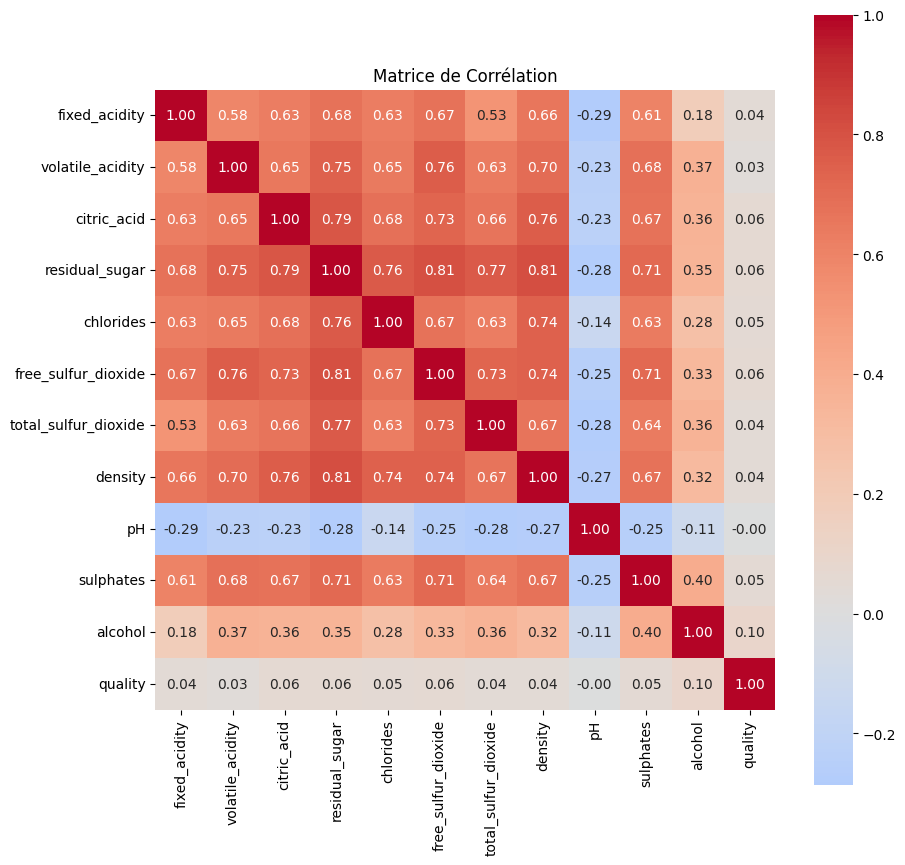

In [15]:
# 8. Heatmap des corrélations
plt.figure(figsize=(10,10))
corr_matrix = data_wine.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Matrice de Corrélation')

 
✅ En conclusion, la matrice de corrélation ne nous montre pas d'insight très pertinent.



=== ANALYSE EXPLORATOIRE (EDA) ===
Statistiques descriptives:
       fixed_acidity  volatile_acidity   citric_acid  residual_sugar  \
count   14940.000000      14940.000000  14940.000000    14940.000000   
mean        9.619956          0.746201      0.762662       29.421767   
std         2.440643          0.369823      0.392536       19.674421   
min         3.800000          0.080000      0.000000        0.600000   
25%         7.300000          0.370000      0.370000        6.500000   
50%         9.700000          0.785000      0.820000       36.000000   
75%        11.600000          1.060000      1.100000       46.200000   
max        15.900000          1.580000      1.660000       65.800000   

          chlorides  free_sulfur_dioxide  total_sulfur_dioxide       density  \
count  14940.000000         14940.000000          14940.000000  14940.000000   
mean       0.190994           122.365000            220.594525      1.008847   
std        0.126539            78.780757        

(-1.0999999999632648, 1.099999999234645, -1.0999997273189919, 1.09999998701519)

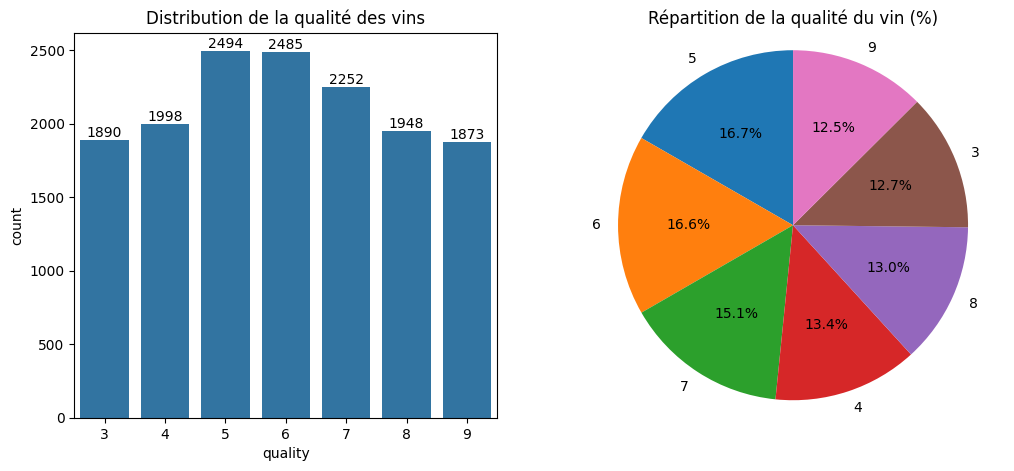

In [16]:
# 2.1 EDA - ANALYSE EXPLORATOIRE DÉTAILLÉE
print("\n=== ANALYSE EXPLORATOIRE (EDA) ===")

# Statistiques descriptives
print("Statistiques descriptives:")
print(data_wine.describe())
data_brute_wine_quality = data_wine.copy()

# EDA Visualisations
plt.figure(figsize=(12, 5))

# 1. Répartition de la qualité des vins
plt.subplot(1, 2, 1)
ax = sns.countplot(x='quality',data=data_brute_wine_quality)
plt.title('Distribution de la qualité des vins')
ax.bar_label(ax.containers[0])

plt.subplot(1, 2, 2)
wine_quality = data_brute_wine_quality['quality'].value_counts(normalize=True)*100
plt.pie(wine_quality.values, labels=wine_quality.index, autopct='%1.1f%%', startangle=90)
plt.title('Répartition de la qualité du vin (%)')
plt.axis('equal')  





🎯 D'après nos observations, il n'y a que très peu de données au niveau des extremums. De plus au vu des performances sur ce jeux de données avec autant de classes et aussi peu de data, les modèles ne dépassent jamais 68%. Ici nous allons donc réduire à 5 classes pour obtenir un modèle plus pertinent. 

In [17]:
# # Regroupe classes numériques
# data_brute_wine_quality['quality_binned'] = data_brute_wine_quality['quality'].replace({
#     3: 4,  # 3 → 4
#     9: 8   # 9 → 8
# })

# print("Répartition quality originale:", data_brute_wine_quality['quality'].value_counts().sort_index())
# print("Répartition quality_binned:", data_brute_wine_quality['quality_binned'].value_counts().sort_index())
# # EDA Visualisations
# plt.figure(figsize=(12, 5))

# # 1. Répartition de la qualité des vins
# plt.subplot(1, 2, 1)
# ax = sns.countplot(x='quality_binned',data=data_brute_wine_quality)
# plt.title('Distribution de la qualité des vins')
# ax.bar_label(ax.containers[0])

# plt.subplot(1, 2, 2)
# wine_quality = data_brute_wine_quality['quality_binned'].value_counts(normalize=True)*100
# plt.pie(wine_quality.values, labels=wine_quality.index, autopct='%1.1f%%', startangle=90)
# plt.title('Répartition de la qualité du vin (%)')
# plt.axis('equal')  

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, '(0.99, 0.992]'),
  Text(1, 0, '(0.992, 0.994]'),
  Text(2, 0, '(0.994, 0.996]'),
  Text(3, 0, '(0.996, 0.998]'),
  Text(4, 0, '(0.998, 1.1]')])

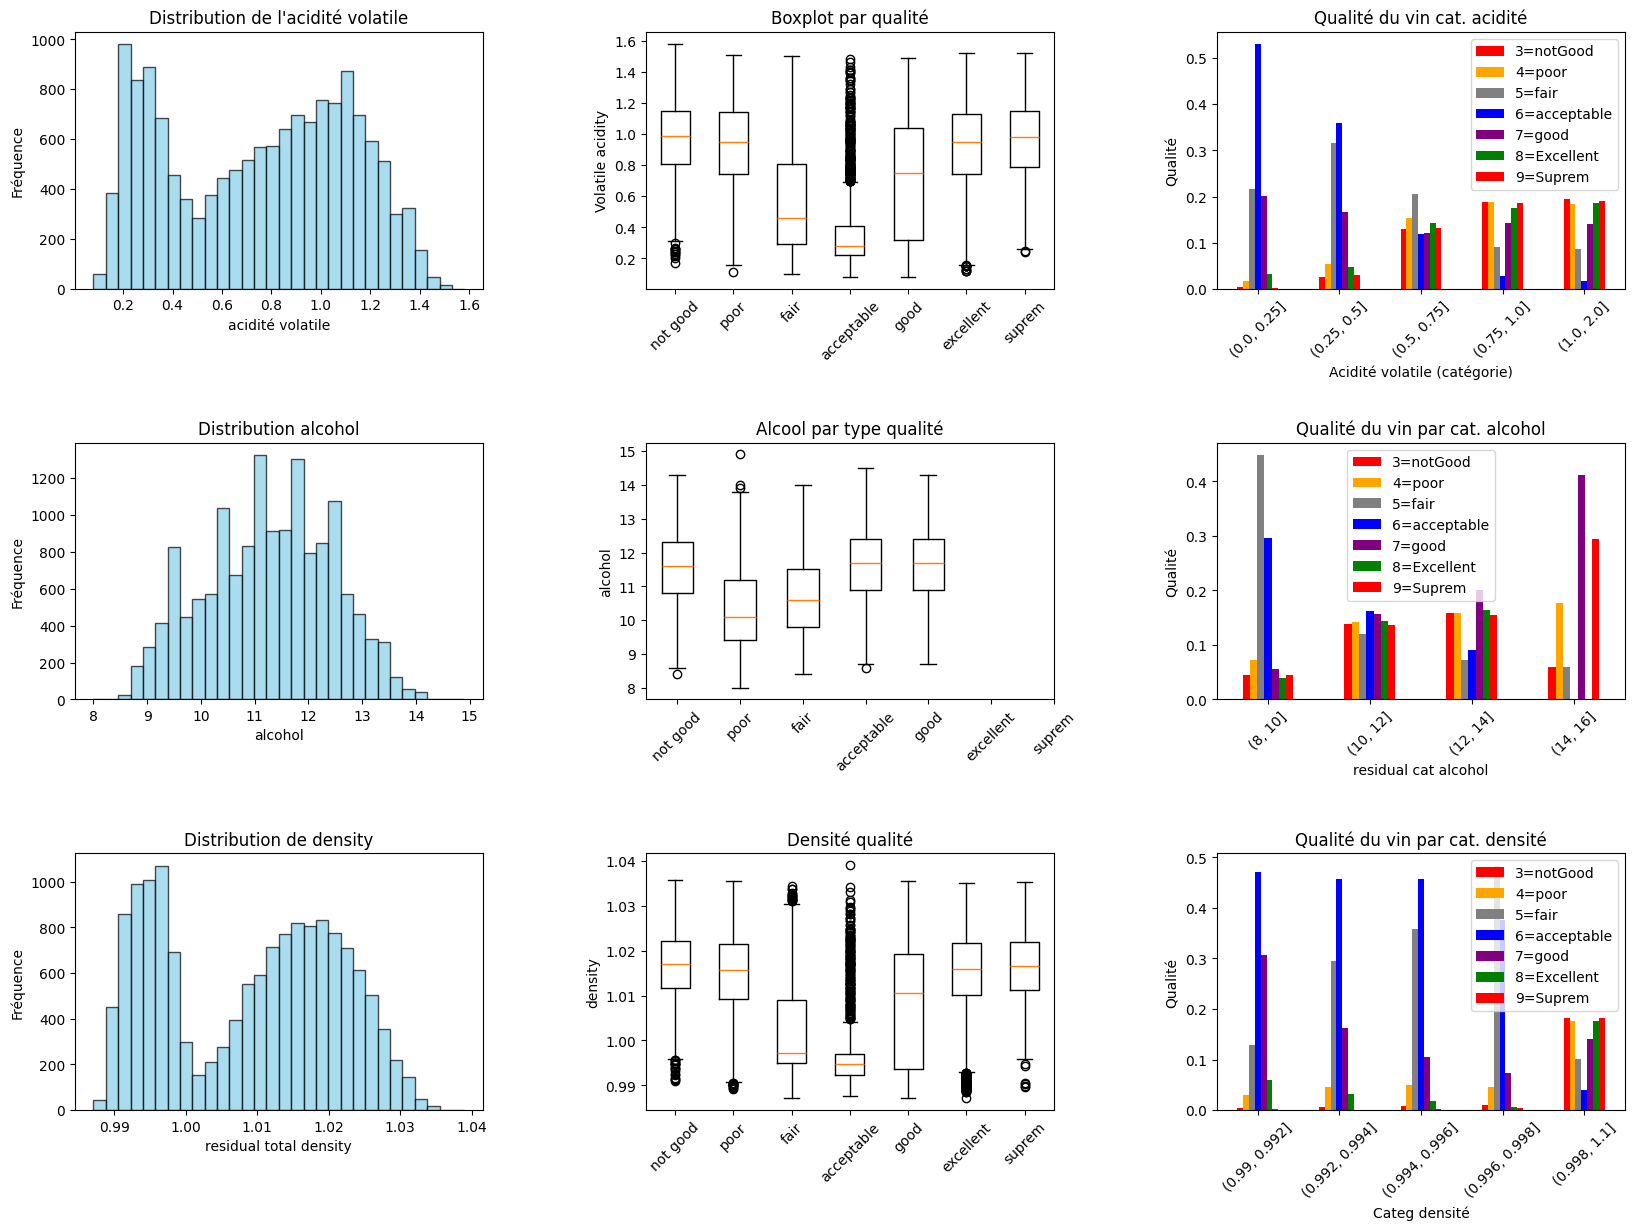

In [78]:
# EDA Visualisations
fig = plt.figure(figsize=(20, 30))  # +30 hauteur
gs = gridspec.GridSpec(6, 3, hspace=0.6, wspace=0.4)  # hspace ↑ 0.6
## ------- ACIDITE VOLATILE ---------------

# # 2.1 Distribution 
plt.subplot(gs[0, 0])  # Ligne 0, colonne 0
plt.hist(data_brute_wine_quality['volatile_acidity'].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution de l\'acidité volatile')
plt.xlabel('acidité volatile')
plt.ylabel('Fréquence')

# ------ Boxplot
plt.subplot(gs[0, 1])  # Ligne 0, colonne 1
not_good_quality = data_brute_wine_quality[data_brute_wine_quality['quality'] == 3]['volatile_acidity'].dropna()
poor_quality = data_brute_wine_quality[data_brute_wine_quality['quality'] == 4]['volatile_acidity'].dropna()
fair_quality = data_brute_wine_quality[data_brute_wine_quality['quality'] == 5]['volatile_acidity'].dropna()
acceptable_quality = data_brute_wine_quality[data_brute_wine_quality['quality'] == 6]['volatile_acidity'].dropna()
good_quality = data_brute_wine_quality[data_brute_wine_quality['quality'] == 7]['volatile_acidity'].dropna()
excellent_quality = data_brute_wine_quality[data_brute_wine_quality['quality'] == 8]['volatile_acidity'].dropna()
suprem_quality = data_brute_wine_quality[data_brute_wine_quality['quality'] == 9]['volatile_acidity'].dropna()

bp = plt.boxplot([not_good_quality,poor_quality, fair_quality, acceptable_quality, good_quality, excellent_quality,suprem_quality])
plt.title('Boxplot par qualité')
plt.ylabel('Volatile acidity')
plt.xticks([1, 2, 3, 4, 5,6,7], ['not good','poor', 'fair', 'acceptable', 'good', 'excellent','suprem'], rotation=45)


# -------- Qualité par catégorie de volatile acidity
#init
bins = [0, 0.25, 0.5, 0.75, 1.0, 2.0]
labels=['Très faible', 'Faible', 'Moyen', 'Élevé', 'Très élevé']
color=['red', 'orange', 'grey', 'blue', 'purple', 'green']
legend = ['3=notGood','4=poor', '5=fair', '6=acceptable','7=good','8=Excellent','9=Suprem']
# create column categ
data_brute_wine_quality['volatile_acidity_cat'] = pd.cut(data_brute_wine_quality['volatile_acidity'], bins, labels)
quality_by_volatile_acidity_cat = pd.crosstab(data_brute_wine_quality['volatile_acidity_cat'], 
                                             data_brute_wine_quality['quality'], 
                                             normalize='index')
plt.subplot(gs[0, 2])  # Ligne 0, colonne 2
quality_by_volatile_acidity_cat.plot(kind='bar', color=color, ax=plt.gca())
plt.title('Qualité du vin cat. acidité')
plt.xlabel('Acidité volatile (catégorie)')
plt.ylabel('Qualité')
plt.legend(legend)
plt.xticks(rotation=45)





# 4 Distribution alcohol
plt.subplot(gs[1, 0])
plt.hist(data_brute_wine_quality['alcohol'].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution alcohol')
plt.xlabel('alcohol')
plt.ylabel('Fréquence')

# ------ Boxplot
plt.subplot(gs[1, 1])
poor_quality = data_brute_wine_quality[data_brute_wine_quality['quality'] == 3]['alcohol'].dropna()
poor_quality = data_brute_wine_quality[data_brute_wine_quality['quality'] == 4]['alcohol'].dropna()
fair_quality = data_brute_wine_quality[data_brute_wine_quality['quality'] == 5]['alcohol'].dropna()
acceptable_quality = data_brute_wine_quality[data_brute_wine_quality['quality'] == 6]['alcohol'].dropna()
good_quality = data_brute_wine_quality[data_brute_wine_quality['quality'] == 7]['alcohol'].dropna()
excellent_quality = data_brute_wine_quality[data_brute_wine_quality['quality'] == 8]['alcohol'].dropna()
excellent_quality = data_brute_wine_quality[data_brute_wine_quality['quality'] == 9]['alcohol'].dropna()

bp = plt.boxplot([poor_quality, fair_quality, acceptable_quality, good_quality, excellent_quality])
plt.title('Alcool par type qualité')
plt.ylabel('alcohol')
plt.xticks([1, 2, 3, 4, 5,6,7], ['not good','poor', 'fair', 'acceptable', 'good', 'excellent','suprem'], rotation=45)


# -------- Qualité par cat alcohol
bins = [8, 10, 12, 14,16]
data_brute_wine_quality['alcohol_cat'] = pd.cut(data_brute_wine_quality['alcohol'], bins, labels)
quality_by_alcohol_cat = pd.crosstab(data_brute_wine_quality['alcohol_cat'], 
                                             data_brute_wine_quality['quality'], 
                                             normalize='index')
plt.subplot(gs[1, 2])
quality_by_alcohol_cat.plot(kind='bar', color=color, ax=plt.gca())
plt.title('Qualité du vin par cat. alcohol')
plt.xlabel('residual cat alcohol')
plt.ylabel('Qualité')
plt.legend(legend)
plt.xticks(rotation=45)


# # 8 Distribution de densité
plt.subplot(gs[2, 0])
plt.hist(data_brute_wine_quality['density'].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution de density')
plt.xlabel('residual total density')
plt.ylabel('Fréquence')
#------ Boxplot
plt.subplot(gs[2, 1])
not_good_quality = data_brute_wine_quality[data_brute_wine_quality['quality'] == 3]['density'].dropna()
poor_quality = data_brute_wine_quality[data_brute_wine_quality['quality'] == 4]['density'].dropna()
fair_quality = data_brute_wine_quality[data_brute_wine_quality['quality'] == 5]['density'].dropna()
acceptable_quality = data_brute_wine_quality[data_brute_wine_quality['quality'] == 6]['density'].dropna()
good_quality = data_brute_wine_quality[data_brute_wine_quality['quality'] == 7]['density'].dropna()
excellent_quality = data_brute_wine_quality[data_brute_wine_quality['quality'] == 8]['density'].dropna()
suprem_quality = data_brute_wine_quality[data_brute_wine_quality['quality'] == 9]['density'].dropna()

bp = plt.boxplot([not_good_quality,poor_quality, fair_quality, acceptable_quality, good_quality, excellent_quality,suprem_quality])
plt.title('Densité qualité')
plt.ylabel('density')
plt.xticks([1, 2, 3, 4, 5,6,7], ['not good','poor', 'fair', 'acceptable', 'good', 'excellent','suprem'], rotation=45)


# -------- Qualité par density
bins = [0.99, 0.992, 0.994, 0.996, 0.998, 1.1]
data_brute_wine_quality['density_cat'] = pd.cut(data_brute_wine_quality['density'], bins, labels)
quality_by_density_cat = pd.crosstab(data_brute_wine_quality['density_cat'], 
                                             data_brute_wine_quality['quality'], 
                                             normalize='index')
plt.subplot(gs[2, 2])
quality_by_density_cat.plot(kind='bar', color=color, ax=plt.gca())
plt.title('Qualité du vin par cat. densité')
plt.xlabel('Categ densité')
plt.ylabel('Qualité')
plt.legend(legend)
plt.xticks(rotation=45)



In [18]:
#suppression des colonnes ajouté
cols_to_drop = ['volatile_acidity_cat', 'alcohol_cat', 'density_cat']

data_brute_wine_quality = data_brute_wine_quality.drop(columns=cols_to_drop, errors='ignore')

# Etape 2 : Preprocessing

### Principales étapes du pré-processing :
1. Gestion des valeurs manquantes ==> pas besoins ici
2. Normalisation/Standardisation ==> convertir les données
3. Encodage des variables catégorielles
4. Division des données (train/test)

### 2.1 Nettoyage et traitement des données  

Dans ce jeux de données il n'y a pas de valeur manquante ni d'outliers

In [19]:
data = data_brute_wine_quality.copy()

# 3. PREPROCESSING ET FEATURE ENGINEERING

# Sélection des features pertinentes
features = ['volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']
#features =['alcohol', 'volatile acidity', 'sulphates', 'chlorides', 'density']
x = data[features].copy()
y = data['quality']
print(x.info()) #Toutes les données sont en float

<class 'pandas.core.frame.DataFrame'>
Index: 14940 entries, 0 to 20994
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   volatile_acidity      14940 non-null  float64
 1   citric_acid           14940 non-null  float64
 2   residual_sugar        14940 non-null  float64
 3   chlorides             14940 non-null  float64
 4   chlorides             14940 non-null  float64
 5   free_sulfur_dioxide   14940 non-null  float64
 6   total_sulfur_dioxide  14940 non-null  float64
 7   density               14940 non-null  float64
 8   pH                    14940 non-null  float64
 9   sulphates             14940 non-null  float64
 10  alcohol               14940 non-null  float64
dtypes: float64(11)
memory usage: 1.4 MB
None


### 2.2 Séparation du jeu d'entrainement vs test

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print(f"Taille train: {x_train.shape[0]} échantillons")
print(f"Taille test: {x_test.shape[0]} échantillons")
print(y.value_counts())

Taille train: 11952 échantillons
Taille test: 2988 échantillons
quality
5    2494
6    2485
7    2252
4    1998
8    1948
3    1890
9    1873
Name: count, dtype: int64


### 2.3 Création d'un set de validation

In [36]:
# Stratified split 80/20 
X_train, X_val, Y_train, Y_val = train_test_split(
    x_train, y_train, 
    test_size=0.2,          # 20% val
    stratify=y_train,       # PRESERVE les proportions 60-40
    random_state=42         # Reproductible
)

print(f"Train final: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {x_test.shape[0]}")
print(Y_train.value_counts())

Train final: 9561, Val: 2391, Test: 2988
quality
5    1596
6    1590
7    1442
4    1278
8    1246
3    1210
9    1199
Name: count, dtype: int64


# Etape 3 : Pipeline

Dans ce jeu de données, la qualité du vin est répartie en 7 classes, avec davantage d’exemples dans les classes 5 et 6, et moins dans les classes plus rares.
Pour éviter qu’un déséquilibre entre les classes n’influence trop l’apprentissage, nous évaluons les modèles avec **F1 macro** et **precision macro**. L’accuracy est aussi observée, mais elle peut masquer les erreurs sur les classes minoritaires 

Objectif 1 : Ne pas faire de la sur promesses de qualité. Exemple : typer un vin classe 6 ou 7 en classe 8.
On va tester plusieurs modeles à la fois sur le f1_macro et le precision_macro. 

Ensuite, en regroupant les labels en 3 classes, l’équilibre devient plus correct. Nous avons donc comparé les modèles avec **precision** et **accuracy**, car dans ce cas l’accuracy devient plus lisible pour juger la performance globale

### 3.1 Pipeline Preprocessing et Grid search - Random Forest

**Random Forest**  
Utilisation du RandomForestClassifier  
1- scoring='f1_macro'   
2- scoring='precision_macro' 

#### 3.1.1 - Random Forest - toutes les catégories (7) - F1_macro & Precision

In [ ]:
# # RANDOM FOREST 
# print("\n=== GRIDS SEARCH RANDOM FOREST : f1_macro ===")

# # a- Pipeline COMPLETE (scaler + modèle)
# pipeline_rf = Pipeline([
#     ('scaler', StandardScaler()),
#     ('rf', RandomForestClassifier(random_state=42))
# ])
# # b- Définition des hyperparamètres à tester
# param_grid_rf = {
#     'rf__n_estimators': [200,300], #plus d'arbre modele + stable mais + lent
#     'rf__max_depth': [10,20,30], #limiter la profoncdeur pour réduire l'overfit
#     'rf__min_samples_split': [50,100], #permettre des splits plus fins >1 si integer
#     'rf__min_samples_leaf': [20,30],
#     'rf__max_features': ['sqrt', 'log2'],  # sous‑échantillonnage des features
#     'rf__class_weight': [ 'balanced'],      # gérer le déséquilibre éventuel entre les classes important dans ce dataset
#     'rf__max_samples': [0.7, 0.8]

# }

# # c- Configuration de la validation croisée: méthode pour évaluer le meilleur modele en utilisant une validation croisée stratifié à 3 plis (folds)
# cv_strategy = StratifiedKFold(
#     n_splits=5, # données divisée en 3 plis ==> modele entrainé et évalué 5 fois
#     shuffle=True, # les données sont mélangées avant d'etre divisées pour éviter tout biais
#     random_state=42) 

# # d- Grille de recherche
# grid_search_rf = GridSearchCV(
#     pipeline_rf, param_grid_rf, 
#     scoring='f1_macro', cv=cv_strategy, n_jobs=-1, verbose=1
# )

# # e. Entraînement du modèle avec GridSearch
# #x_preprocessed = pipeline_preprocessing.fit_transform(x_train_scaled)
# grid_search_rf.fit(X_train, Y_train)
# print("Meilleurs params:", grid_search_rf.best_params_)
# print(f"CV score: {grid_search_rf.best_score_:.3f}")

# # Entraînement du modèle avec les meilleurs hyperparamètres
# best_rf = grid_search_rf.best_estimator_
# print(f"Meilleur best model random forest: {best_rf}")

# #-------------------------------------------------

# # Predcition
# y_train_pred = best_rf.predict(X_train)
# y_val_pred = best_rf.predict(X_val)
# y_test_pred = best_rf.predict(x_test)

# # 📊 CALCUL + STOCKAGE AUTO
# f1_train = f1_score(Y_train, y_train_pred, average='macro')
# f1_val = f1_score(Y_val, y_val_pred, average='macro')
# prec_train = precision_score(Y_train, y_train_pred, average='macro')
# prec_val = precision_score(Y_val, y_val_pred, average='macro')

# print(f"F1_macro train: {f1_train:.2%} | Val: {f1_val:.2%}")
# print(f"Precision_macro train: {prec_train:.2%} | Val: {prec_val:.2%}")

# # 0. INIT (1x seulement)
# results_comparison = []
# # STOCKAGE
# results_comparison.append({
#     'Test': 'RF_f1_macro',
#     'F1_Train': f1_train,
#     'F1_Val': f1_val,
#     'Prec_Train': prec_train,
#     'Prec_Val': prec_val
# })


# # e. ÉVALUATION COMPLÈTE
# print("\n=== MÉTRIQUES SUR JEU D'ENTRAÎNEMENT RANDOM FOREST scoring = f1_macro ===")
# print(f"✅Accuracy train: {accuracy_score(Y_train, y_train_pred):.2%}")
# print(f"✅Precision_macro train: {precision_score(Y_train, y_train_pred, average='macro'):.2%}")
# print(f"✅Recall_macro train: {recall_score(Y_train, y_train_pred, average='macro'):.2%}")
# print(f"✅F1_macro train: {f1_score(Y_train, y_train_pred, average='macro'):.2%}")
# print(f"\n ✅ Val F1: {f1_score(Y_val, y_val_pred, average='macro'):.2%}") 

# print("\n=== MÉTRIQUES SUR JEU DE TEST RANDOM FOREST scoring = f1_macro ===")
# print(f"✅Accuracy test: {accuracy_score(y_test, y_test_pred):.2%}")
# print(f"✅Precision_macro test: {precision_score(y_test, y_test_pred, average='macro'):.2%}")
# print(f"✅Recall_macro test: {recall_score(y_test, y_test_pred, average='macro'):.2%}")
# print(f"✅F1_macro test: {f1_score(y_test, y_test_pred, average='macro'):.2%}")

# # Rapport de classification détaillé
# print("\n=== RAPPORT DÉTAILLÉ TEST ===")
# print(classification_report(y_test, y_test_pred))

# cm_rf1=confusion_matrix(y_test, y_test_pred)



=== GRIDS SEARCH RANDOM FOREST : f1_macro ===
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Meilleurs params: {'rf__class_weight': 'balanced', 'rf__max_depth': 30, 'rf__max_features': 'sqrt', 'rf__max_samples': 0.8, 'rf__min_samples_leaf': 20, 'rf__min_samples_split': 50, 'rf__n_estimators': 200}
CV score: 0.287
Meilleur best model random forest: Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestClassifier(class_weight='balanced', max_depth=30,
                                        max_samples=0.8, min_samples_leaf=20,
                                        min_samples_split=50, n_estimators=200,
                                        random_state=42))])
F1_macro train: 57.89% | Val: 28.41%
Precision_macro train: 63.10% | Val: 33.31%

=== MÉTRIQUES SUR JEU D'ENTRAÎNEMENT RANDOM FOREST scoring = f1_macro ===
✅Accuracy train: 60.20%
✅Precision_macro train: 63.10%
✅Recall_macro train: 61.56%
✅F1_macro train: 57.89%

 ✅ V

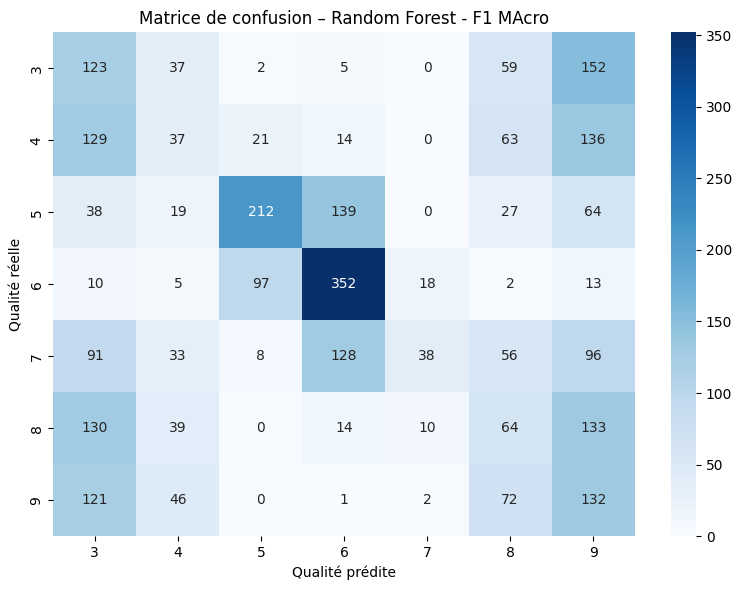

In [ ]:
# # Visualisation de la matrice de confusion
# labels = ['3', '4', '5', '6', '7', '8', '9']  

# plt.figure(figsize=(8, 6))
# sns.heatmap(
#     cm_rf1,
#     annot=True,           # montre les chiffres dans les cases
#     fmt='d',              # affiche en entiers, pas en float
#     cmap='Blues',
#     xticklabels=labels,   # classes prédites
#     yticklabels=labels,   # classes réelles
# )
# plt.title('Matrice de confusion – Random Forest - F1 MAcro')
# plt.xlabel('Qualité prédite')
# plt.ylabel('Qualité réelle')
# plt.tight_layout()
# plt.show()

Conclusion : le modèle a de bon résultat sur la classe 6, mais il est très faible sur la majeur partie des classes. Il y a beaucoup de confusion entre classes voisines, malgré le changement d'hyperparamètres. 
On va relancer avec le précision macro avant de potentiellement passer en 3 classes distincts : mauvais, correct, bon.

In [ ]:
# # RANDOM FOREST scoring = precision macro
# print("\n=== GRIDS SEARCH RANDOM FOREST : macro precision ===")

# # a -Pipeline COMPLÈTE (scaler + modèle)  ✅ AJOUTÉ
# pipeline_rf2 = Pipeline([
#     ('scaler', StandardScaler()),
#     ('rf', RandomForestClassifier(random_state=42))
# ])

# # b- Définition des hyperparamètres à tester
# param_grid_rf2 = {
#     'rf__n_estimators': [200,300],  
#     'rf__max_depth': [15,25], # pas trop grand pour eviter overfitting
#     'rf__min_samples_split': [5,10,20],
#     'rf__min_samples_leaf': [1,3,5], #ne pas avoir 1 pour eviter overfitting
#     'rf__max_features': ['sqrt',0.7],
#     'rf__class_weight': ['balanced']  
# }

# # c- Configuration de la validation croisée 
# cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 

# # d- Grille de recherche
# #precision_macro : chaque classe à une voix donc pénalise les classes rares
# #precision_weighted : chaque classe est pondérée par son nombre d'occurrences
# grid_search_rf2 = GridSearchCV(
#     pipeline_rf2, param_grid_rf2, 
#     scoring='f1_macro', cv=cv_strategy, n_jobs=-1, verbose=1  # ✅ precision_macro
# )

# # e- Entraînement du modèle avec GridSearch
# grid_search_rf2.fit(X_train, Y_train) 

# # f- Meilleurs hyperparamètres
# print("\nMeilleurs hyperparamètres trouvés pour Random FOrest:", grid_search_rf2.best_params_)
# best_rf2 = grid_search_rf2.best_estimator_

# #---------------------------------------------

# # g- Prediction
# y_train_pred = best_rf2.predict(X_train)
# y_val_pred = best_rf2.predict(X_val) 
# y_test_pred = best_rf2.predict(x_test)


# # 📊 CALCUL + STOCKAGE AUTO
# f1_train2 = f1_score(Y_train, y_train_pred, average='macro')
# f1_val2 = f1_score(Y_val, y_val_pred, average='macro')
# prec_train2 = precision_score(Y_train, y_train_pred, average='macro')
# prec_val2 = precision_score(Y_val, y_val_pred, average='macro')

# print(f"F1_macro train: {f1_train2:.2%} | Val: {f1_val2:.2%}")
# print(f"Precision_macro train: {prec_train2:.2%} | Val: {prec_val2:.2%}")

# # STOCKAGE
# results_comparison.append({
#     'Test2': 'RF_precision_macro',
#     'F1_Train2': f1_train2,
#     'F1_Val2': f1_val2,
#     'Prec_Train2': prec_train2,
#     'Prec_Val2': prec_val2
# })



# # Métriques train
# print("\n=== MÉTRIQUES SUR JEU D'ENTRAÎNEMENT RANDOM FOREST scoring = precision macro===")
# print(f"✅Accuracy train: {accuracy_score(Y_train, y_train_pred):.2%}")
# print(f"✅Precision_macro train: {precision_score(Y_train, y_train_pred, average='macro'):.2%}")
# print(f"✅Recall_macro train: {recall_score(Y_train, y_train_pred, average='macro'):.2%}")
# print(f"✅F1_macro train: {f1_score(Y_train, y_train_pred, average='macro'):.2%}")
# print(f"\n ✅ Val Precision score: {precision_score(Y_val, y_val_pred, average='macro'):.2%}") 

# print("\n=== MÉTRIQUES SUR JEU DE TEST RANDOM FOREST scoring = precision macro===")
# print(f"✅Accuracy test: {accuracy_score(y_test, y_test_pred):.2%}")
# print(f"✅Precision_macro test: {precision_score(y_test, y_test_pred, average='macro'):.2%}")
# print(f"✅Recall_macro test: {recall_score(y_test, y_test_pred, average='macro'):.2%}")
# print(f"✅F1_macro test: {f1_score(y_test, y_test_pred, average='macro'):.2%}")

# print("\n=== RAPPORT DÉTAILLÉ TEST ===")
# print(classification_report(y_test, y_test_pred))

# print("\n=== MATRICE DE CONFUSION TEST ===")
# print(confusion_matrix(y_test, y_test_pred))
# cm_rf2=confusion_matrix(y_test, y_test_pred)


=== GRIDS SEARCH RANDOM FOREST : macro precision ===
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Meilleurs hyperparamètres trouvés pour Random FOrest: {'rf__class_weight': 'balanced', 'rf__max_depth': 15, 'rf__max_features': 0.7, 'rf__min_samples_leaf': 3, 'rf__min_samples_split': 10, 'rf__n_estimators': 200}
F1_macro train: 82.24% | Val: 29.33%
Precision_macro train: 83.54% | Val: 32.11%

=== MÉTRIQUES SUR JEU D'ENTRAÎNEMENT RANDOM FOREST scoring = precision macro===
✅Accuracy train: 82.38%
✅Precision_macro train: 83.54%
✅Recall_macro train: 83.60%
✅F1_macro train: 82.24%

 ✅ Val Precision score: 32.11%

=== MÉTRIQUES SUR JEU DE TEST RANDOM FOREST scoring = precision macro===
✅Accuracy test: 32.63%
✅Precision_macro test: 34.29%
✅Recall_macro test: 31.40%
✅F1_macro test: 30.46%

=== RAPPORT DÉTAILLÉ TEST ===
              precision    recall  f1-score   support

           3       0.19      0.29      0.23       378
           4       0.21      0.15      0.18       4

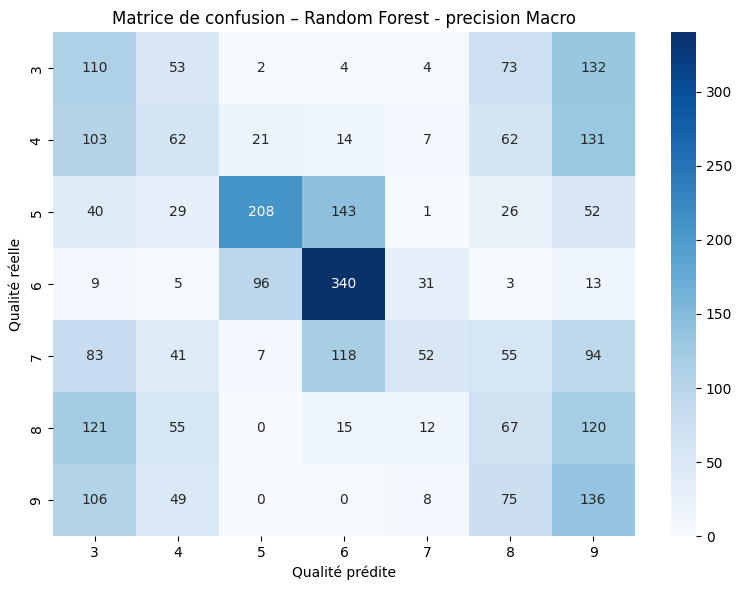

In [ ]:
# #matrice de confusion Precision MAcro
# labels = ['3', '4', '5', '6', '7', '8', '9']  

# plt.figure(figsize=(8, 6))
# sns.heatmap(
#     cm_rf2,
#     annot=True,           # montre les chiffres dans les cases
#     fmt='d',              # affiche en entiers, pas en float
#     cmap='Blues',
#     xticklabels=labels,   # classes prédites
#     yticklabels=labels,   # classes réelles
# )
# plt.title('Matrice de confusion – Random Forest - precision Macro')
# plt.xlabel('Qualité prédite')
# plt.ylabel('Qualité réelle')
# plt.tight_layout()
# plt.show()

Conclusion : le modèle a de con résultat sur la classe 6, mais il est très faible sur la majeur partie des classes. Il y a beaucoup de confusion entre classes voisines, malgré le changement d'hyperparamètres. 
On va relancer avec le précision macro avant de potentiellement passer en 3 classes distincts : mauvais, correct, bon.

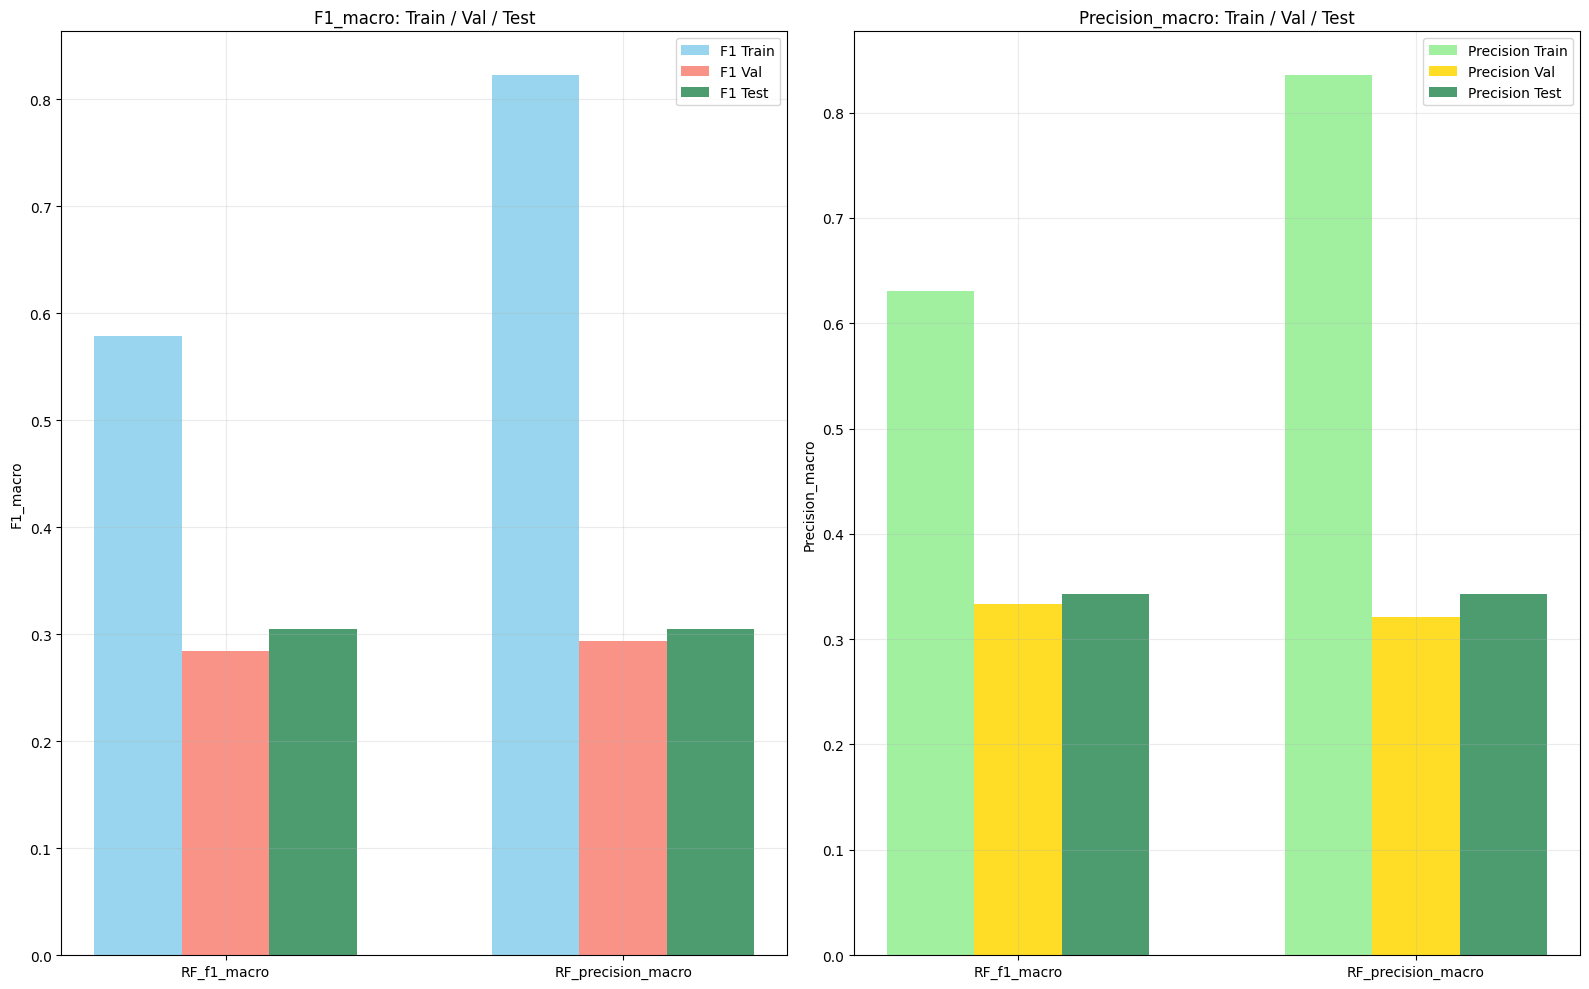

In [ ]:
# # DataFrame avec vos résultats déjà calculés
# df_results = pd.DataFrame([
#     {
#         'Test': 'RF_f1_macro',
#         'F1_Train': f1_train,
#         'F1_Val': f1_val,
#         'F1_Test': f1_score(y_test, y_test_pred, average='macro'),
#         'Prec_Train': prec_train,
#         'Prec_Val': prec_val,
#         'Prec_Test': precision_score(y_test, y_test_pred, average='macro')
#     },
#     {
#         'Test': 'RF_precision_macro',
#         'F1_Train': f1_train2,
#         'F1_Val': f1_val2,
#         'F1_Test': f1_score(y_test, y_test_pred, average='macro'),
#         'Prec_Train': prec_train2,
#         'Prec_Val': prec_val2,
#         'Prec_Test': precision_score(y_test, y_test_pred, average='macro')
#     }
# ])

# # Couleurs fixes et cohérentes
# colors_f1 = ['skyblue', 'salmon', 'seagreen']
# colors_prec = ['lightgreen', 'gold', 'seagreen']

# x = np.arange(len(df_results))
# width = 0.22

# #-------


# fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# # F1
# axes[0].bar(x - width, df_results['F1_Train'], width, label='F1 Train', color=colors_f1[0], alpha=0.85)
# axes[0].bar(x, df_results['F1_Val'], width, label='F1 Val', color=colors_f1[1], alpha=0.85)
# axes[0].bar(x + width, df_results['F1_Test'], width, label='F1 Test', color=colors_f1[2], alpha=0.85)
# axes[0].set_title('F1_macro: Train / Val / Test')
# axes[0].set_ylabel('F1_macro')
# axes[0].set_xticks(x)
# axes[0].set_xticklabels(df_results['Test'])
# axes[0].legend()
# axes[0].grid(alpha=0.25)



# # Precision
# axes[1].bar(x - width, df_results['Prec_Train'], width, label='Precision Train', color=colors_prec[0], alpha=0.85)
# axes[1].bar(x, df_results['Prec_Val'], width, label='Precision Val', color=colors_prec[1], alpha=0.85)
# axes[1].bar(x + width, df_results['Prec_Test'], width, label='Precision Test', color=colors_prec[2], alpha=0.85)
# axes[1].set_title('Precision_macro: Train / Val / Test')
# axes[1].set_ylabel('Precision_macro')
# axes[1].set_xticks(x)
# axes[1].set_xticklabels(df_results['Test'])
# axes[1].legend()
# axes[1].grid(alpha=0.25)

# plt.tight_layout()
# plt.show()

🚀 Conclusion :  
Beaucoup d'overfitting lors de l'entrainement
Ce modele ne généralise pas bien sur ce problème ==> fort écart entre le train et validation/test

#### 3.1.2 - Créer un dataset à 3 classes

In [30]:
data_brute_wine_quality_2 = data_brute_wine_quality.copy()

data_brute_wine_quality_2['quality_3class'] = data_brute_wine_quality_2['quality'].replace({
    3: 0, 4: 0,        # low
    5: 1, 6: 1,        # medium
    7: 2, 8: 2, 9: 2   # high
})

print(data_brute_wine_quality_2.columns)
data2 = data_brute_wine_quality_2.copy()

print("\nRépartition quality_3class:")
print(data2['quality_3class'].value_counts().sort_index())

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'quality_3class'],
      dtype='object')

Répartition quality_3class:
quality_3class
0    3888
1    4979
2    6073
Name: count, dtype: int64


In [29]:
print(data2['quality_3class'].dtype)
print(data2['quality_3class'].head())
print(data2.dtypes)


int64
0    0
1    0
2    0
3    0
4    0
Name: quality_3class, dtype: int64
fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
quality_3class            int64
dtype: object


In [31]:
# 3. PREPROCESSING ET FEATURE ENGINEERING

# Sélection des features pertinentes
#features = ['volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']

x2 = data2.drop(columns=['quality', 'quality_3class'])
y2 = data2['quality_3class']
print(x2.info()) #Toutes les données sont en float

<class 'pandas.core.frame.DataFrame'>
Index: 14940 entries, 0 to 20994
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         14940 non-null  float64
 1   volatile_acidity      14940 non-null  float64
 2   citric_acid           14940 non-null  float64
 3   residual_sugar        14940 non-null  float64
 4   chlorides             14940 non-null  float64
 5   free_sulfur_dioxide   14940 non-null  float64
 6   total_sulfur_dioxide  14940 non-null  float64
 7   density               14940 non-null  float64
 8   pH                    14940 non-null  float64
 9   sulphates             14940 non-null  float64
 10  alcohol               14940 non-null  float64
dtypes: float64(11)
memory usage: 1.4 MB
None


In [32]:
#CREATION JEU DE TEST
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, random_state=42, stratify=y2)
print(f"Taille train: {x2_train.shape[0]} échantillons")
print(f"Taille test: {x2_test.shape[0]} échantillons")
print(y2.value_counts())

Taille train: 11952 échantillons
Taille test: 2988 échantillons
quality_3class
2    6073
1    4979
0    3888
Name: count, dtype: int64


In [33]:
# CREATION JEU DE VALIDATION
# Stratified split 80/20 
X2_train, X2_val, Y2_train, Y2_val = train_test_split(
    x2_train, y2_train, 
    test_size=0.2,          # 20% val
    stratify=y2_train,       # PRESERVE les proportions 60-40
    random_state=42         # Reproductible
)

print(f"Train final: {X2_train.shape[0]}, Val: {X2_val.shape[0]}, Test: {x2_test.shape[0]}")

Train final: 9561, Val: 2391, Test: 2988


#### 3.2.2 Random FOREST - 3 categories - Precision & Accuracy

In [ ]:
# RANDOM FOREST 
print("\n=== GRIDS SEARCH RANDOM FOREST : precision ===")

# a- Pipeline COMPLETE (scaler + modèle)
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])
# b- Définition des hyperparamètres à tester
param_grid_rf = {
    'rf__n_estimators': [300,500], #plus d'arbre modele + stable mais + lent
    'rf__max_depth': [12, 16, 20], #limiter la profoncdeur pour réduire l'overfit
    'rf__min_samples_split': [5, 10, 20], #si trop haut => sous apprendre, si trop bas => overfitting
    'rf__min_samples_leaf': [2, 5, 10],
    'rf__max_features': ['sqrt', 'log2', 0.5],  # sous‑échantillonnage des features
    'rf__class_weight': [ 'balanced', 'balanced_subsample'],      # gérer le déséquilibre éventuel entre les classes important dans ce dataset
    'rf__max_samples': [0.7, 0.8,0.9]

}

# c- Configuration de la validation croisée: méthode pour évaluer le meilleur modele en utilisant une validation croisée stratifié à 3 plis (folds)
cv_strategy = StratifiedKFold(
    n_splits=5, # données divisée en 3 plis ==> modele entrainé et évalué 5 fois
    shuffle=True, # les données sont mélangées avant d'etre divisées pour éviter tout biais
    random_state=42) 

# d- Grille de recherche
grid_search_rf = GridSearchCV(
    pipeline_rf, param_grid_rf, 
    scoring='precision_macro', cv=cv_strategy, n_jobs=-1, verbose=1
)

# e. Entraînement du modèle avec GridSearch
#x_preprocessed = pipeline_preprocessing.fit_transform(x_train_scaled)
grid_search_rf.fit(X2_train, Y2_train)
print("Meilleurs params:", grid_search_rf.best_params_)
print(f"CV score: {grid_search_rf.best_score_:.3f}")

# Entraînement du modèle avec les meilleurs hyperparamètres
best_rf = grid_search_rf.best_estimator_
print(f"Meilleur best model random forest: {best_rf}")

#-------------------------------------------------

# Predcition
y2_train_pred = best_rf.predict(X2_train)
y2_val_pred = best_rf.predict(X2_val)
y2_test_pred = best_rf.predict(x2_test)

# 📊 CALCUL + STOCKAGE AUTO
f1_train2 = f1_score(Y2_train, y2_train_pred, average='macro')
f1_val2 = f1_score(Y2_val, y2_val_pred, average='macro')
prec_train2 = precision_score(Y2_train, y2_train_pred, average='macro')
prec_val2 = precision_score(Y2_val, y2_val_pred, average='macro')

print(f"F1_macro train: {f1_train2:.2%} | Val: {f1_val2:.2%}")
print(f"Precision_macro train: {prec_train2:.2%} | Val: {prec_val2:.2%}")

# 0. INIT (1x seulement)
results_comparison = []
# STOCKAGE
results_comparison.append({
    'Test': 'RF_f1_macro',
    'F1_Train': f1_train2,
    'F1_Val': f1_val2,
    'Prec_Train': prec_train2,
    'Prec_Val': prec_val2
})


# e. ÉVALUATION COMPLÈTE
print("\n=== MÉTRIQUES SUR JEU D'ENTRAÎNEMENT RANDOM FOREST scoring = precison ===")
print(f"✅Accuracy train: {accuracy_score(Y2_train, y2_train_pred):.2%}")
print(f"✅Precision_macro train: {precision_score(Y2_train, y2_train_pred, average='macro'):.2%}")
print(f"✅Recall_macro train: {recall_score(Y2_train, y2_train_pred, average='macro'):.2%}")
print(f"✅F1_macro train: {f1_score(Y2_train, y2_train_pred, average='macro'):.2%}")
print(f"\n ✅ Val Precision score: {precision_score(Y2_val, y2_val_pred, average='macro'):.2%}") 

print("\n=== MÉTRIQUES SUR JEU DE TEST RANDOM FOREST scoring = precison ===")
print(f"✅Accuracy test: {accuracy_score(y2_test, y2_test_pred):.2%}")
print(f"✅Precision_macro test: {precision_score(y2_test, y2_test_pred, average='macro'):.2%}")
print(f"✅Recall_macro test: {recall_score(y2_test, y2_test_pred, average='macro'):.2%}")
print(f"✅F1_macro test: {f1_score(y2_test, y2_test_pred, average='macro'):.2%}")

# Rapport de classification détaillé
print("\n=== RAPPORT DÉTAILLÉ TEST ===")
print(classification_report(y2_test, y2_test_pred))

cm_rf3=confusion_matrix(y2_test, y2_test_pred)



=== GRIDS SEARCH RANDOM FOREST : precision ===
Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Meilleurs params: {'rf__class_weight': 'balanced_subsample', 'rf__max_depth': 20, 'rf__max_features': 0.5, 'rf__max_samples': 0.8, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 500}
CV score: 0.580
Meilleur best model random forest: Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=20, max_features=0.5,
                                        max_samples=0.8, min_samples_leaf=2,
                                        min_samples_split=5, n_estimators=500,
                                        random_state=42))])
F1_macro train: 93.54% | Val: 56.92%
Precision_macro train: 93.75% | Val: 57.82%

=== MÉTRIQUES SUR JEU D'ENTRAÎNEMENT RANDOM FOREST scoring = precison ===
✅Accuracy train: 93.53%
✅Precision_mac

In [ ]:
# RANDOM FOREST scoring = average
print("\n=== GRIDS SEARCH RANDOM FOREST : average ===")

# a -Pipeline COMPLÈTE (scaler + modèle)  ✅ AJOUTÉ
pipeline_rf2 = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

# b- Définition des hyperparamètres à tester
param_grid_rf2 = {
    'rf__n_estimators': [200,300,500],  
    'rf__max_depth': [12, 15, 20], # pas trop grand pour eviter overfitting
    'rf__min_samples_split': [5,10,20],
    'rf__min_samples_leaf': [2,3,5], #ne pas avoir 1 pour eviter overfitting
    'rf__max_features': ['sqrt',0.7],
    'rf__class_weight': ['balanced', 'balanced_subsample']  
}

# c- Configuration de la validation croisée 
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 

# d- Grille de recherche
#precision_macro : chaque classe à une voix donc pénalise les classes rares
#precision_weighted : chaque classe est pondérée par son nombre d'occurrences
grid_search_rf2 = GridSearchCV(
    pipeline_rf2, param_grid_rf2, 
    scoring='accuracy', cv=cv_strategy, n_jobs=-1, verbose=1  # ✅ precision_macro
)

# e- Entraînement du modèle avec GridSearch
grid_search_rf2.fit(X2_train, Y2_train) 

# f- Meilleurs hyperparamètres
print("\nMeilleurs hyperparamètres trouvés pour Random FOrest:", grid_search_rf2.best_params_)
best_rf2 = grid_search_rf2.best_estimator_

#---------------------------------------------

# g- Prediction
y2_train_pred = best_rf2.predict(X2_train)
y2_val_pred = best_rf2.predict(X2_val) 
y2_test_pred = best_rf2.predict(x2_test)


# 📊 CALCUL + STOCKAGE AUTO
acc_train2 = accuracy_score(Y2_train, y2_train_pred)
acc_val2 = accuracy_score(Y2_val, y2_val_pred)
prec_train2 = precision_score(Y2_train, y2_train_pred, average='macro')
prec_val2 = precision_score(Y2_val, y2_val_pred, average='macro')

print(f"Accuracy train: {acc_train2:.2%} | Val: {acc_val2:.2%}")
print(f"Precision_macro train: {prec_train2:.2%} | Val: {prec_val2:.2%}")

# STOCKAGE
results_comparison.append({
    'Test2': 'RF_precision_macro',
    'Accuracy_Train2': acc_train2,
    'Accuracy_Val2': acc_val2,
    'Prec_Train2': prec_train2,
    'Prec_Val2': prec_val2
})



# Métriques train
print("\n=== MÉTRIQUES SUR JEU D'ENTRAÎNEMENT RANDOM FOREST scoring = accuracy ===")
print(f"✅Accuracy train: {accuracy_score(Y2_train, y2_train_pred):.2%}")
print(f"✅Precision_macro train: {precision_score(Y2_train, y2_train_pred, average='macro'):.2%}")
print(f"✅Recall_macro train: {recall_score(Y2_train, y2_train_pred, average='macro'):.2%}")
print(f"✅F1_macro train: {f1_score(Y2_train, y2_train_pred, average='macro'):.2%}")
print(f"\n ✅ Accuracy: {accuracy_score(Y2_val, y2_val_pred):.2%}") 

print("\n=== MÉTRIQUES SUR JEU DE TEST RANDOM FOREST scoring = accuracy ===")
print(f"✅Accuracy test: {accuracy_score(y2_test, y2_test_pred):.2%}")
print(f"✅Precision_macro test: {precision_score(y2_test, y2_test_pred, average='macro'):.2%}")
print(f"✅Recall_macro test: {recall_score(y2_test, y2_test_pred, average='macro'):.2%}")
print(f"✅F1_macro test: {f1_score(y2_test, y2_test_pred, average='macro'):.2%}")

print("\n=== RAPPORT DÉTAILLÉ TEST ===")
print(classification_report(y2_test, y2_test_pred))

cm_rf4=confusion_matrix(y2_test, y2_test_pred)


=== GRIDS SEARCH RANDOM FOREST : average ===
Fitting 5 folds for each of 432 candidates, totalling 2160 fits


c:\Users\alexa\Documents\IA_Alyra\IA_Alyra\Semaine 5 - ML\Code Live ML Partie 2\Training_ML_AM\.venv_clean\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Meilleurs hyperparamètres trouvés pour Random FOrest: {'rf__class_weight': 'balanced_subsample', 'rf__max_depth': 25, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 500}
Accuracy train: 99.04% | Val: 60.75%
Precision_macro train: 99.05% | Val: 58.44%

=== MÉTRIQUES SUR JEU D'ENTRAÎNEMENT RANDOM FOREST scoring = accuracy ===
✅Accuracy train: 99.04%
✅Precision_macro train: 99.05%
✅Recall_macro train: 99.04%
✅F1_macro train: 99.05%

 ✅ Accuracy: 60.75%

=== MÉTRIQUES SUR JEU DE TEST RANDOM FOREST scoring = accuracy ===
✅Accuracy test: 59.92%
✅Precision_macro test: 56.57%
✅Recall_macro test: 56.11%
✅F1_macro test: 55.11%

=== RAPPORT DÉTAILLÉ TEST ===
              precision    recall  f1-score   support

           0       0.34      0.18      0.23       778
           1       0.83      0.80      0.82       992
           2       0.53      0.71      0.60      1214

    accuracy                           0.60      2984
   macro avg   

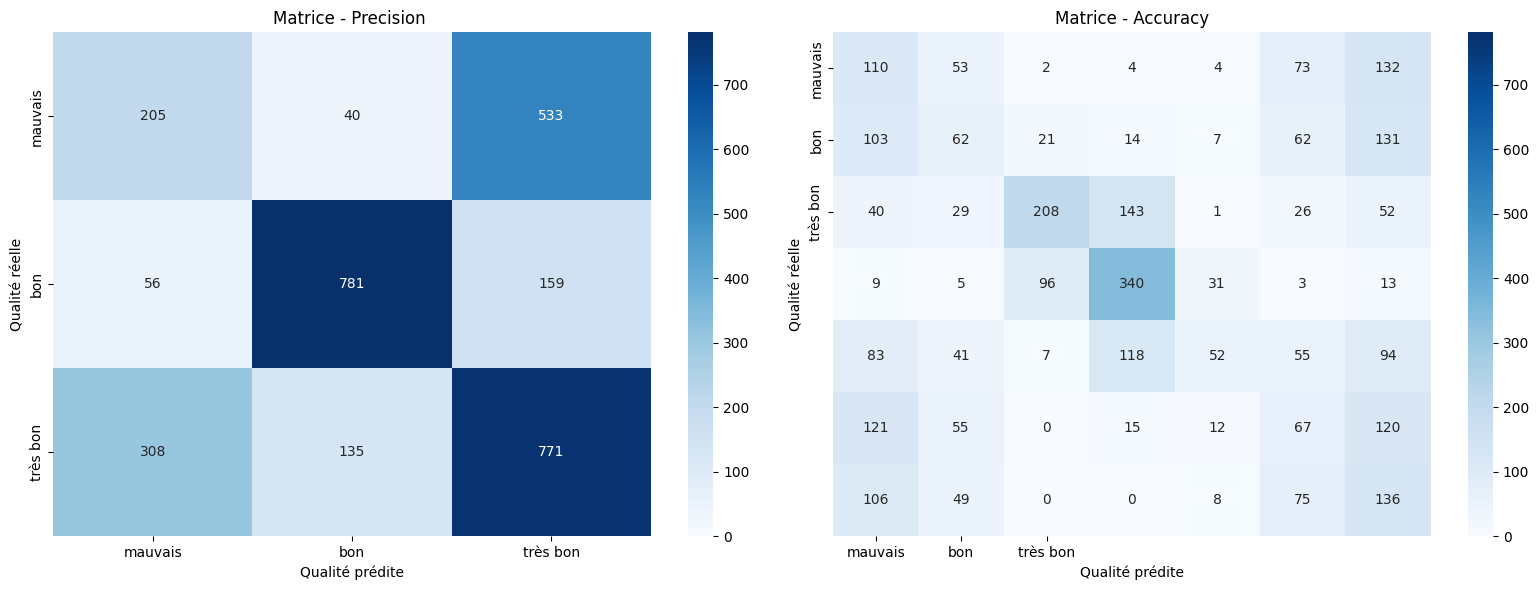

In [ ]:
# Visualisation de la matrice de confusion
labels = ['mauvais', 'bon', 'très bon']  
vmax = max(cm_rf3.max(), cm_rf4.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_rf3, annot=True, fmt='d', cmap='Blues', vmin=0, vmax=vmax,
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Matrice - Precision ')
axes[0].set_xlabel('Qualité prédite')
axes[0].set_ylabel('Qualité réelle')

sns.heatmap(cm_rf4, annot=True, fmt='d', cmap='Blues', vmin=0, vmax=vmax,
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Matrice - Accuracy')
axes[1].set_xlabel('Qualité prédite')
axes[1].set_ylabel('Qualité réelle')

plt.tight_layout()
plt.show()

Conclusion :  
On s'aperçoit que le modèle est très fragile pour les cas extrêmes. 
Dans ce dataset, uniquement les caractéristiques physico-chimique sont pris en compte, sans prendre en compte le goût, les années, le cépages... Potentiellement les limites entre mauvais et très bon sont difficiles à séparer avec les features actuelles. 

### 3.2 Pipeline Preprocessing et Grid search - AdaBoost

Utilisation du AdaBoostClassifier  
1- scoring='f1_macro'  
2- scoring='precision_macro'  

==> pas optimisé ! on oublie !

In [ ]:
# # Boosting > model AdaBoost
# print("\n=== GRIDS SEARCH POUR MODEL = ADABOOST TREE : f1_macro===")
# # Définition du modèle de base
# weak_learner = DecisionTreeClassifier(max_depth=2)

# # a- Pipeline COMPLÈTE  ✅ AJOUTÉ
# pipeline_ada = Pipeline([
#     ('scaler', StandardScaler()),
#     ('ada', AdaBoostClassifier(estimator=weak_learner, random_state=42))
# ])

# # b- Définition des hyperparamètres à tester
# param_grid_ada = {
#     'ada__n_estimators': [200, 300, 500],
#     'ada__learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'ada__estimator__max_depth': [1, 2, 3],
#     'ada__estimator__min_samples_leaf': [1, 2, 5]
# }
# # c- Configuration de la validation croisée 
# cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# # d- Grille de recherche
# grid_search_ada = GridSearchCV(
#     pipeline_ada, param_grid_ada,
#     scoring='f1_macro', cv=cv_strategy, n_jobs=-1, verbose=1, error_score="raise"
# )

# # e- Entraînement du modèle avec GridSearch
# grid_search_ada.fit(X_train, Y_train)


# # Meilleurs hyperparamètres
# print("\nMeilleurs hyperparamètres trouvés pour AdaBoost Tree:", grid_search_ada.best_params_)
# # Meilleur score
# print(f"Meilleur score de validation pour AdaBoost Tree: {grid_search_ada.best_score_:.2%}")
# best_ada = grid_search_ada.best_estimator_
# print(f"Meilleur best model ada tree: {best_ada}")

# # Performance modele sur un jeu de test indépendant
# print("\naccuracy data de test : ", grid_search_ada.score(x_test, y_test)*100)


# # Prédictions
# y_train_pred = best_ada.predict(X_train)
# y_val_pred = best_ada.predict(X_val)
# y_test_pred = best_ada.predict(x_test)

# # 📊 CALCUL + STOCKAGE AUTO
# f1_train = f1_score(Y_train, y_train_pred, average='macro')
# f1_val = f1_score(Y_val, y_val_pred, average='macro')
# prec_train = precision_score(Y_train, y_train_pred, average='macro')
# prec_val = precision_score(Y_val, y_val_pred, average='macro')

# print(f"F1_macro train: {f1_train:.2%} | Val: {f1_val:.2%}")
# print(f"Precision_macro train: {prec_train:.2%} | Val: {prec_val:.2%}")

# # STOCKAGE
# results_comparison.append({
#     'Test': 'ADA_f1_macro',
#     'F1_Train': f1_train,
#     'F1_Val': f1_val,
#     'Prec_Train': prec_train,
#     'Prec_Val': prec_val
# })

# # Métriques train
# print("\n=== MÉTRIQUES SUR JEU D'ENTRAÎNEMENT ADABOOST TREE scoring = f1_macro===")
# print(f"✅Accuracy train: {accuracy_score(Y_train, y_train_pred):.2%}")
# print(f"✅Precision_macro train: {precision_score(Y_train, y_train_pred, average='macro'):.2%}")
# print(f"✅Recall_macro train: {recall_score(Y_train, y_train_pred, average='macro'):.2%}")
# print(f"✅F1_macro train: {f1_score(Y_train, y_train_pred, average='macro'):.2%}")
# print(f"✅Val F1: {f1_score(Y_val, y_val_pred, average='macro'):.3%}")

# print("\n=== MÉTRIQUES SUR JEU DE TEST ADABOOST TREE scoring = f1_macro===")
# print(f"✅Accuracy test: {accuracy_score(y_test, y_test_pred):.2%}")
# print(f"✅Precision_macro test: {precision_score(y_test, y_test_pred, average='macro'):.2%}")
# print(f"✅Recall_macro test: {recall_score(y_test, y_test_pred, average='macro'):.2%}")
# print(f"✅F1_macro test: {f1_score(y_test, y_test_pred, average='macro'):.2%}")

# print("\n=== RAPPORT DÉTAILLÉ TEST ===")
# print(classification_report(y_test, y_test_pred))

# print("\n=== MATRICE DE CONFUSION TEST ===")
# print(confusion_matrix(y_test, y_test_pred))



=== GRIDS SEARCH POUR MODEL = ADABOOST TREE : f1_macro===
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Meilleurs hyperparamètres trouvés pour AdaBoost Tree: {'ada__estimator__max_depth': 3, 'ada__estimator__min_samples_leaf': 1, 'ada__learning_rate': 0.2, 'ada__n_estimators': 500}
Meilleur score de validation pour AdaBoost Tree: 29.16%
Meilleur best model ada tree: Pipeline(steps=[('scaler', StandardScaler()),
                ('ada',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),
                                    learning_rate=0.2, n_estimators=500,
                                    random_state=42))])

accuracy data de test :  29.574713664301434
F1_macro train: 32.95% | Val: 29.13%
Precision_macro train: 35.84% | Val: 31.51%

=== MÉTRIQUES SUR JEU D'ENTRAÎNEMENT ADABOOST TREE scoring = f1_macro===
✅Accuracy train: 34.68%
✅Precision_macro train: 35.84%
✅Recall_macro train: 33.61%
✅F1_macro train: 32.95%
✅Val F1: 29.126%

=== M

In [ ]:
# # 6.2 Boosting > model AdaBoost
# print("\n=== GRIDS SEARCH MODEL = ADABOOST TREE : Precision macro ===")
# # Définition du modèle de base
# weak_learner = DecisionTreeClassifier(max_depth=1, random_state=42)

# pipeline_ada_macro = Pipeline([
#     ('scaler', StandardScaler()),
#     ('ada', AdaBoostClassifier(estimator=weak_learner, random_state=42))
# ])

# # Définition des hyperparamètres à tester
# param_grid_ada_macro = {
#     'ada__n_estimators': [200, 300, 500],
#     'ada__learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'ada__estimator__max_depth': [1, 2, 3],
#     'ada__estimator__min_samples_leaf': [1, 2, 5]
# }
# # Configuration de la validation croisée 
# cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# # Grille de recherche
# grid_search_ada_macro = GridSearchCV(
#     pipeline_ada_macro, param_grid_ada_macro,
#     scoring='precision_macro', cv=cv_strategy, n_jobs=-1, verbose=1, error_score="raise"
# )

# # Entraînement du modèle avec GridSearch
# grid_search_ada_macro.fit(X_train, Y_train)

# # Meilleurs hyperparamètres
# print("\nMeilleurs hyperparamètres trouvés pour AdaBoost Tree:",grid_search_ada_macro.best_params_)
# # Meilleur score
# print(f"Meilleur score de validation pour AdaBoost Tree:: {grid_search_ada_macro.best_score_:.2%}")

# best_ada_macro = grid_search_ada_macro.best_estimator_
# print(f"Meilleur best model ada tree: {best_ada_macro}")


# # Prédictions
# y_train_pred = best_ada_macro.predict(X_train)
# y_val_pred = best_ada_macro.predict(X_val)
# y_test_pred = best_ada_macro.predict(x_test)

# # 📊 CALCUL + STOCKAGE AUTO
# f1_train2 = f1_score(Y_train, y_train_pred, average='macro')
# f1_val2 = f1_score(Y_val, y_val_pred, average='macro')
# prec_train2 = precision_score(Y_train, y_train_pred, average='macro')
# prec_val2 = precision_score(Y_val, y_val_pred, average='macro')

# print(f"F1_macro train: {f1_train2:.2%} | Val: {f1_val2:.2%}")
# print(f"Precision_macro train: {prec_train2:.2%} | Val: {prec_val2:.2%}")

# # STOCKAGE
# results_comparison.append({
#     'Test2': 'ADA_precision_macro',
#     'F1_Train2': f1_train2,
#     'F1_Val2': f1_val2,
#     'Prec_Train2': prec_train2,
#     'Prec_Val2': prec_val2
# })

# # Métriques train
# print("\n=== MÉTRIQUES SUR JEU D'ENTRAÎNEMENT ADABOOST TREE scoring = precision macro===")
# print(f"✅Accuracy train: {accuracy_score(Y_train, y_train_pred):.2%}")
# print(f"✅Precision_macro train: {precision_score(Y_train, y_train_pred, average='macro'):.2%}")
# print(f"✅Recall_macro train: {recall_score(Y_train, y_train_pred, average='macro'):.2%}")
# print(f"✅F1_macro train: {f1_score(Y_train, y_train_pred, average='macro'):.2%}")
# print(f"✅Val F1: {f1_score(Y_val, y_val_pred, average='macro'):.3%}") 

# print("\n=== MÉTRIQUES SUR JEU DE TEST ADABOOST TREE scoring = precision macro===")
# print(f"✅Accuracy test: {accuracy_score(y_test, y_test_pred):.2%}")
# print(f"✅Precision_macro test: {precision_score(y_test, y_test_pred, average='macro'):.2%}")
# print(f"✅Recall_macro test: {recall_score(y_test, y_test_pred, average='macro'):.2%}")
# print(f"✅F1_macro test: {f1_score(y_test, y_test_pred, average='macro'):.2%}")

# print("\n=== RAPPORT DÉTAILLÉ TEST ===")
# print(classification_report(y_test, y_test_pred))

# print("\n=== MATRICE DE CONFUSION TEST ===")
# print(confusion_matrix(y_test, y_test_pred))


=== GRIDS SEARCH MODEL = ADABOOST TREE : Precision macro ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Meilleurs hyperparamètres trouvés pour AdaBoost Tree: {'ada__estimator__max_depth': 3, 'ada__estimator__min_samples_leaf': 1, 'ada__learning_rate': 0.2, 'ada__n_estimators': 500}
Meilleur score de validation pour AdaBoost Tree:: 30.94%
Meilleur best model ada tree: Pipeline(steps=[('scaler', StandardScaler()),
                ('ada',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                                     random_state=42),
                                    learning_rate=0.2, n_estimators=500,
                                    random_state=42))])
F1_macro train: 32.95% | Val: 29.13%
Precision_macro train: 35.84% | Val: 31.51%

=== MÉTRIQUES SUR JEU D'ENTRAÎNEMENT ADABOOST TREE scoring = precision macro===
✅Accuracy train: 34.68%
✅Precision_macro train: 35.84%
✅Recall_macro train: 33

📊 Conclusion : Adaboost pas performant pour ce modèle

### 3.3 Pipeline Preprocessing et Grid search - GradientBoostClassifier

Utilisation du GradientBoostClassifier  
1- scoring='f1_macro'  
2- scoring='precision_macro'  

#### 3.3.1 Gradient Boost - 7 classes - F1 score & Precision

In [ ]:
# 6.3 Boosting > model Gradient Boosting
print("\n=== GRIDS SEARCH POUR MODEL Gradient Boosting Tree : f1 macro===")

# Pipeline COMPLÈTE 
pipeline_gbt = Pipeline([
    ('scaler', StandardScaler()),
    ('gbt', GradientBoostingClassifier(random_state=42))
])

# Définition des hyperparamètres à tester
param_grid_gbt = {
    'gbt__n_estimators': [200,400],
    'gbt__learning_rate': [0.01, 0.05, 0.1],
    'gbt__max_depth': [5,9],
    'gbt__min_samples_leaf': [1,3],
    'gbt__min_samples_split': [5,8],
    'gbt__subsample': [0.8, 0.9],
    'gbt__max_features': ['sqrt', 0.8]
}
# Configuration de la validation croisée 
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Grille de recherche
grid_search_gbt = GridSearchCV(
    pipeline_gbt, param_grid_gbt, 
    scoring='f1_macro', cv=cv_strategy, 
    n_jobs=-1, verbose=1, error_score="raise"
)

# Entraînement du modèle avec GridSearch
grid_search_gbt.fit(X_train, Y_train) 

# Meilleurs hyperparamètres
print("\nMeilleurs hyperparamètres trouvés pour AdaBoost Reg Linear:", grid_search_gbt.best_params_)
# Meilleur score
print(f"Meilleur score de validation pour Random Forest: {grid_search_gbt.best_score_:.2%}")

best_gbt = grid_search_gbt.best_estimator_
print(f"Meilleur best model Gradient boost: {best_gbt}")

# Performance modele sur un jeu de test indépendant
print("\naccuracy data de test : ", grid_search_gbt.score(x_test, y_test)*100)

# Prédiction des données d'entraînement
y_train_pred = best_gbt.predict(X_train)
y_val_pred = best_gbt.predict(X_val) 
y_test_pred = best_gbt.predict(x_test)

# 📊 CALCUL + STOCKAGE AUTO
f1_train = f1_score(Y_train, y_train_pred, average='macro')
f1_val = f1_score(Y_val, y_val_pred, average='macro')
prec_train = precision_score(Y_train, y_train_pred, average='macro')
prec_val = precision_score(Y_val, y_val_pred, average='macro')

print(f"F1_macro train: {f1_train:.2%} | Val: {f1_val:.2%}")
print(f"Precision_macro train: {prec_train:.2%} | Val: {prec_val:.2%}")

# STOCKAGE
results_comparison.append({
    'Test': 'RF_f1_macro',
    'F1_Train': f1_train,
    'F1_Val': f1_val,
    'Prec_Train': prec_train,
    'Prec_Val': prec_val
})
# Métriques train
print("\n=== MÉTRIQUES SUR JEU D'ENTRAÎNEMENT GRADIENT BOOSTING scoring :f1 macro===")
print(f"✅Accuracy train: {accuracy_score(Y_train, y_train_pred):.2%}")
print(f"✅Precision_macro train: {precision_score(Y_train, y_train_pred, average='macro'):.2%}")
print(f"✅Recall_macro train: {recall_score(Y_train, y_train_pred, average='macro'):.2%}")
print(f"✅F1_macro train: {f1_score(Y_train, y_train_pred, average='macro'):.2%}")
print(f"✅Val F1: {f1_score(Y_val, y_val_pred, average='macro'):.3%}") 

print("\n=== MÉTRIQUES SUR JEU DE TEST GRADIENT BOOSTING scoring :f1 macro===")
print(f"✅Accuracy test: {accuracy_score(y_test, y_test_pred):.2%}")
print(f"✅Precision_macro test: {precision_score(y_test, y_test_pred, average='macro'):.2%}")
print(f"✅Recall_macro test: {recall_score(y_test, y_test_pred, average='macro'):.2%}")
print(f"✅F1_macro test: {f1_score(y_test, y_test_pred, average='macro'):.2%}")

print("\n=== RAPPORT DÉTAILLÉ TEST ===")
print(classification_report(y_test, y_test_pred))

print("\n=== MATRICE DE CONFUSION TEST ===")
print(confusion_matrix(y_test, y_test_pred))



=== GRIDS SEARCH POUR MODEL Gradient Boosting Tree : f1 macro===
Fitting 5 folds for each of 192 candidates, totalling 960 fits


In [ ]:
# 6.3 Boosting > model Gradient Boosting
print("\n=== GRIDS SEARCH POUR MODEL Gradient Boosting Tree ===")
# Pipeline COMPLÈTE 
pipeline_gbt2 = Pipeline([
    ('scaler', StandardScaler()),
    ('gbt', GradientBoostingClassifier(random_state=42))
])

# Définition des hyperparamètres à tester
param_grid_gbt2 =  {
    'gbt__n_estimators': [300,500],
    # 'gbt__loss': ['log_loss'],
    'gbt__learning_rate': [0.05, 0.1, 0.15],
    'gbt__max_depth': [4,6,8],
    'gbt__min_samples_leaf': [1, 3],
    'gbt__min_samples_split': [5, 10],
    'gbt__subsample': [0.7, 0.8],
    'gbt__max_features': ['sqrt', 0.8]
}
# Configuration de la validation croisée 
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Grille de recherche
grid_search_gbt2 = GridSearchCV(
    pipeline_gbt2, param_grid_gbt2, 
    scoring='precision_macro', cv=cv_strategy, 
    n_jobs=-1, verbose=1, error_score="raise"
)

# Entraînement du modèle avec GridSearch
grid_search_gbt2.fit(X_train, Y_train)

# Meilleurs hyperparamètres
print("\nMeilleurs hyperparamètres trouvés pour Gradient boost:", grid_search_gbt2.best_params_)
# Meilleur score
print(f"Meilleur score de validation pour Gradient boost: {grid_search_gbt2.best_score_:.2%}")

best_gbt2 = grid_search_gbt2.best_estimator_
print(f"Meilleur best model Gradient boost: {best_gbt2}")


# Prédictions
y_train_pred = best_gbt2.predict(X_train)
y_val_pred = best_gbt2.predict(X_val) 
y_test_pred = best_gbt2.predict(x_test)

# Métriques train
print("\n=== MÉTRIQUES SUR JEU D'ENTRAÎNEMENT GRADIENT BOOSTING scoring = precision_macro===")
print(f"✅Accuracy train: {accuracy_score(Y_train, y_train_pred):.2%}")
print(f"✅Precision_macro train: {precision_score(Y_train, y_train_pred, average='macro'):.2%}")
print(f"✅Recall_macro train: {recall_score(Y_train, y_train_pred, average='macro'):.2%}")
print(f"✅F1_macro train: {f1_score(Y_train, y_train_pred, average='macro'):.2%}")
print(f"✅Val Precision: {precision_score(Y_val, y_val_pred, average='macro'):.3%}")

print("\n=== MÉTRIQUES SUR JEU DE TEST GRADIENT BOOSTING scoring = precision_macro===")
print(f"✅Accuracy test: {accuracy_score(y_test, y_test_pred):.2%}")
print(f"✅Precision_macro test: {precision_score(y_test, y_test_pred, average='macro'):.2%}")
print(f"✅Recall_macro test: {recall_score(y_test, y_test_pred, average='macro'):.2%}")
print(f"✅F1_macro test: {f1_score(y_test, y_test_pred, average='macro'):.2%}")

print("\n=== RAPPORT DÉTAILLÉ TEST ===")
print(classification_report(y_test, y_test_pred))

print("\n=== MATRICE DE CONFUSION TEST ===")
print(confusion_matrix(y_test, y_test_pred))




=== GRIDS SEARCH POUR MODEL Gradient Boosting Tree ===
Fitting 5 folds for each of 288 candidates, totalling 1440 fits

Meilleurs hyperparamètres trouvés pour Gradient boost: {'gbt__learning_rate': 0.05, 'gbt__max_depth': 6, 'gbt__max_features': 'sqrt', 'gbt__min_samples_leaf': 3, 'gbt__min_samples_split': 5, 'gbt__n_estimators': 300, 'gbt__subsample': 0.7}
Meilleur score de validation pour Gradient boost: 41.47%
Meilleur best model Gradient boost: Pipeline(steps=[('scaler', StandardScaler()),
                ('gbt',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=6,
                                            max_features='sqrt',
                                            min_samples_leaf=3,
                                            min_samples_split=5,
                                            n_estimators=300, random_state=42,
                                            subsample=0.7))])

=== MÉTRIQUES SUR JEU D'ENTRAÎNEMENT GRADIENT BOOSTING scoring 


=== VISUALISATION ===


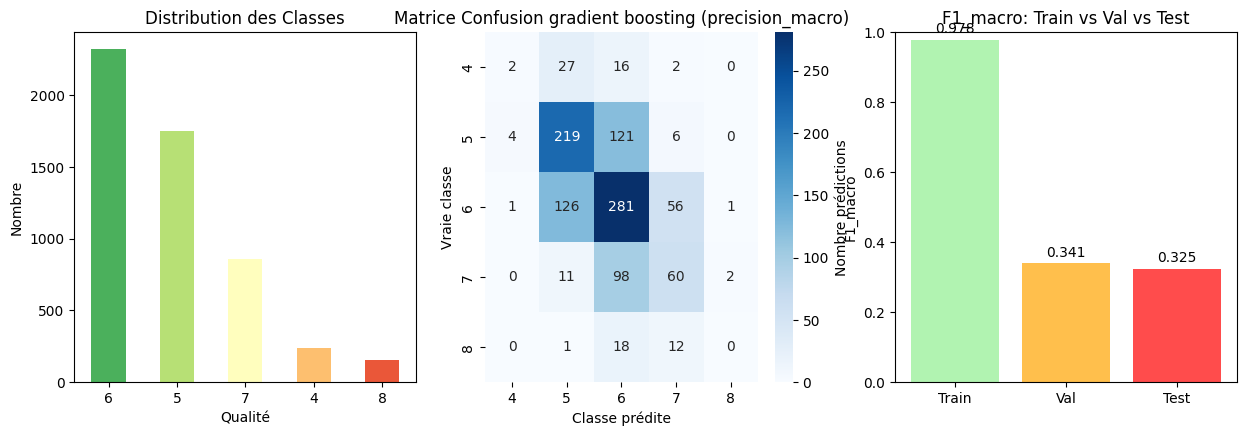

In [ ]:

cm_gdb2 = confusion_matrix(y_test, y_test_pred)
print(cm_gdb2)
# 11. VISUALISATION DES RÉSULTATS
print("\n=== VISUALISATION ===")

# Configuration des graphiques
plt.figure(figsize=(15, 10))

# 1. Distribution des classes
plt.subplot(2, 3, 1)
colors = sns.color_palette("RdYlGn_r", n_colors=5)
y.value_counts().plot(kind='bar', color=colors)
plt.title('Distribution des Classes')
plt.ylabel('Nombre')
plt.xlabel('Qualité')
plt.xticks(rotation=0)

# 2. Matrice de confusion (heatmap)
plt.subplot(2, 3, 2)
labels = ['4','5','6','7','8']  # Vos labels
sns.heatmap(cm_gdb2, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Nombre prédictions'})
plt.title('Matrice Confusion gradient boosting (precision_macro)')
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')

# 3. Comparaison Train vs Test vs Val
plt.subplot(2, 3, 3)
metrics = [f1_score(Y_train, best_gbt2.predict(X_train), average='macro'),
           f1_score(Y_val, best_gbt2.predict(X_val), average='macro'),
           f1_score(y_test, y_test_pred, average='macro')]
labels = ['Train', 'Val', 'Test']
colors = ['lightgreen', 'orange', 'red']
bars = plt.bar(labels, metrics, color=colors, alpha=0.7)
plt.title('F1_macro: Train vs Val vs Test')
plt.ylabel('F1_macro')
plt.ylim(0, 1)
for bar, m in zip(bars, metrics):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{m:.3f}', ha='center', va='bottom')


📊 Conclusion : GRADIENT BOOSTING n'a pas une performance optimale sur ce modèle de donnée

#### 3.3.1 Grandient Boot - Precision & Accuracy

In [ ]:
# 6.3 Boosting > model Gradient Boosting
print("\n=== GRIDS SEARCH Gradient Boosting : Precision ==")
# Pipeline COMPLÈTE 
pipeline_gbt2 = Pipeline([
    ('scaler', StandardScaler()),
    ('gbt', GradientBoostingClassifier(random_state=42))
])

# Définition des hyperparamètres à tester
param_grid_gbt2 =  {
    'gbt__n_estimators': [300,500],
    # 'gbt__loss': ['log_loss'],
    'gbt__learning_rate': [0.05, 0.1, 0.15],
    'gbt__max_depth': [4,6,8],
    'gbt__min_samples_leaf': [1, 3],
    'gbt__min_samples_split': [5, 10],
    'gbt__subsample': [0.7, 0.8],
    'gbt__max_features': ['sqrt', 0.8]
}
# Configuration de la validation croisée 
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Grille de recherche
grid_search_gbt2 = GridSearchCV(
    pipeline_gbt2, param_grid_gbt2, 
    scoring='precision_macro', cv=cv_strategy, 
    n_jobs=-1, verbose=1, error_score="raise"
)

# Entraînement du modèle avec GridSearch
grid_search_gbt2.fit(X2_train, Y2_train)

# Meilleurs hyperparamètres
print("\nMeilleurs hyperparamètres trouvés pour Gradient boost:", grid_search_gbt2.best_params_)
# Meilleur score
print(f"Meilleur score de validation pour Gradient boost: {grid_search_gbt2.best_score_:.2%}")

best_gbt2 = grid_search_gbt2.best_estimator_
print(f"Meilleur best model Gradient boost: {best_gbt2}")


# Prédictions
y2_train_pred = best_gbt2.predict(X2_train)
y2_val_pred = best_gbt2.predict(X2_val) 
y2_test_pred = best_gbt2.predict(x2_test)

# Métriques train
print("\n=== MÉTRIQUES SUR JEU D'ENTRAÎNEMENT GRADIENT BOOSTING scoring = precision_macro===")
print(f"✅Accuracy train: {accuracy_score(Y2_train, y2_train_pred):.2%}")
print(f"✅Precision_macro train: {precision_score(Y2_train, y2_train_pred, average='macro'):.2%}")
print(f"✅Recall_macro train: {recall_score(Y2_train, y2_train_pred, average='macro'):.2%}")
print(f"✅F1_macro train: {f1_score(Y2_train, y2_train_pred, average='macro'):.2%}")
print(f"✅Val Precision: {precision_score(Y2_val, y2_val_pred, average='macro'):.3%}")

print("\n=== MÉTRIQUES SUR JEU DE TEST GRADIENT BOOSTING scoring = precision_macro===")
print(f"✅Accuracy test: {accuracy_score(y2_test, y2_test_pred):.2%}")
print(f"✅Precision_macro test: {precision_score(y2_test, y2_test_pred, average='macro'):.2%}")
print(f"✅Recall_macro test: {recall_score(y2_test, y2_test_pred, average='macro'):.2%}")
print(f"✅F1_macro test: {f1_score(y2_test, y2_test_pred, average='macro'):.2%}")

print("\n=== RAPPORT DÉTAILLÉ TEST ===")
print(classification_report(y2_test, y2_test_pred))

cm_gb3 = confusion_matrix(y2_test, y2_test_pred)

In [ ]:
# 6.3 Boosting > model Gradient Boosting
print("\n=== GRIDS SEARCH Gradient Boosting : Accuracy ==")
# Pipeline COMPLÈTE 
pipeline_gbt2 = Pipeline([
    ('scaler', StandardScaler()),
    ('gbt', GradientBoostingClassifier(random_state=42))
])

# Définition des hyperparamètres à tester
param_grid_gbt2 =  {
    'gbt__n_estimators': [300,500],
    # 'gbt__loss': ['log_loss'],
    'gbt__learning_rate': [0.05, 0.1, 0.15],
    'gbt__max_depth': [4,6,8],
    'gbt__min_samples_leaf': [1, 3],
    'gbt__min_samples_split': [5, 10],
    'gbt__subsample': [0.7, 0.8],
    'gbt__max_features': ['sqrt', 0.8]
}
# Configuration de la validation croisée 
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Grille de recherche
grid_search_gbt2 = GridSearchCV(
    pipeline_gbt2, param_grid_gbt2, 
    scoring='accuracy', cv=cv_strategy, 
    n_jobs=-1, verbose=1, error_score="raise"
)

# Entraînement du modèle avec GridSearch
grid_search_gbt2.fit(X2_train, Y2_train)

# Meilleurs hyperparamètres
print("\nMeilleurs hyperparamètres trouvés pour Gradient boost:", grid_search_gbt2.best_params_)
# Meilleur score
print(f"Meilleur score de validation pour Gradient boost: {grid_search_gbt2.best_score_:.2%}")

best_gbt2 = grid_search_gbt2.best_estimator_
print(f"Meilleur best model Gradient boost: {best_gbt2}")


# Prédictions
y2_train_pred = best_gbt2.predict(X2_train)
y2_val_pred = best_gbt2.predict(X2_val) 
y2_test_pred = best_gbt2.predict(x2_test)

# Métriques train
print("\n=== MÉTRIQUES SUR JEU D'ENTRAÎNEMENT GRADIENT BOOSTING scoring = accuracy===")
print(f"✅Accuracy train: {accuracy_score(Y2_train, y2_train_pred):.2%}")
print(f"✅Precision_macro train: {precision_score(Y2_train, y2_train_pred, average='macro'):.2%}")
print(f"✅Recall_macro train: {recall_score(Y2_train, y2_train_pred, average='macro'):.2%}")
print(f"✅F1_macro train: {f1_score(Y2_train, y2_train_pred, average='macro'):.2%}")
print(f"✅Val Accuracy: {accuracy_score(Y2_val, y2_val_pred):.3%}")

print("\n=== MÉTRIQUES SUR JEU DE TEST GRADIENT BOOSTING scoring = accuracy===")
print(f"✅Accuracy test: {accuracy_score(y2_test, y2_test_pred):.2%}")
print(f"✅Precision_macro test: {precision_score(y2_test, y2_test_pred, average='macro'):.2%}")
print(f"✅Recall_macro test: {recall_score(y2_test, y2_test_pred, average='macro'):.2%}")
print(f"✅F1_macro test: {f1_score(y2_test, y2_test_pred, average='macro'):.2%}")

print("\n=== RAPPORT DÉTAILLÉ TEST ===")
print(classification_report(y2_test, y2_test_pred))

cm_gb4 = confusion_matrix(y2_test, y2_test_pred)

In [ ]:
# Visualisation de la matrice de confusion
labels = ['mauvais', 'bon', 'très bon']  
vmax = max(cm_gb3.max(), cm_gb4.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_gb3, annot=True, fmt='d', cmap='Blues', vmin=0, vmax=vmax,
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Matrice - Precision ')
axes[0].set_xlabel('Qualité prédite')
axes[0].set_ylabel('Qualité réelle')

sns.heatmap(cm_gb4, annot=True, fmt='d', cmap='Blues', vmin=0, vmax=vmax,
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Matrice - Accuracy')
axes[1].set_xlabel('Qualité prédite')
axes[1].set_ylabel('Qualité réelle')

plt.tight_layout()
plt.show()

### 3.4 Pipeline Preprocessing et Grid search - KNN

Utilisation du KNeighborsClassifier()   
1- scoring='f1_accuracy'  
2- scoring='precision_macro'  

#### 3.4.1 KNN - toutes les catégories (7)

In [ ]:
# # Model KNN
# print("\n=== GRIDS SEARCH POUR HYPERPARAMÈTRES KNN -f1_score===")

# pipeline_knn = Pipeline([
#     ('scaler', StandardScaler()),
#     ('knn', KNeighborsClassifier())
# ])
# # Définition des hyperparamètres à tester
# param_grid_knn = {
#     'knn__n_neighbors': [15, 20, 25, 30, 35, 40, 50], # plus grand pour éviter l'overfitting 
#     'knn__weights': ['uniform'],  # 'uniform' pour moins d'overfitting
#     'knn__metric': ['euclidean', 'manhattan', 'minkowski', 'chebyshev']
# }
# # Configuration de la validation croisée 
# cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# # Grille de recherche
# grid_search_knn = GridSearchCV(
#     pipeline_knn, param_grid_knn, 
#     scoring='f1_macro', cv=cv_strategy, 
#     n_jobs=-1, verbose=1, error_score="raise"
# )

# # Sélectionne seulement les features les plus corrélées à quality
# important_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'chlorides']
# X_train_sel = X_train[important_features]
# X_val_sel = X_val[important_features]
# x_test_sel = x_test[important_features]

# # Relance ton GridSearch dessus
# grid_search_knn.fit(X_train_sel, Y_train)

# # Meilleurs hyperparamètres
# print("\nMeilleurs hyperparamètres trouvés pour KNN:",grid_search_knn.best_params_)

# # Meilleur score
# print(f"Meilleur score de validation pour KNN: {grid_search_knn.best_score_:.2%}")

# best_knn = grid_search_knn.best_estimator_
# print(f"Meilleur best model KNN: {best_knn}")


# # Prédictions
# y_train_pred = best_knn.predict(X_train_sel)
# y_val_pred = best_knn.predict(X_val_sel)
# y_test_pred = best_knn.predict(x_test_sel)

# # Métriques train
# print("\n=== MÉTRIQUES TRAIN KNN -f1_score ===")
# print(f"✅Accuracy train: {accuracy_score(Y_train, y_train_pred):.2%}")
# print(f"✅Precision_macro train: {precision_score(Y_train, y_train_pred, average='macro'):.2%}")
# print(f"✅Recall_macro train: {recall_score(Y_train, y_train_pred, average='macro'):.2%}")
# print(f"✅F1_macro train: {f1_score(Y_train, y_train_pred, average='macro'):.2%}")
# print(f"✅Val F1: {f1_score(Y_val, y_val_pred, average='macro'):.3%}")


# print("\n=== MÉTRIQUES TEST KNN -f1_score ===")
# print(f"✅Accuracy test: {accuracy_score(y_test, y_test_pred):.2%}")
# print(f"✅Precision_macro test: {precision_score(y_test, y_test_pred, average='macro'):.2%}")
# print(f"✅Recall_macro test: {recall_score(y_test, y_test_pred, average='macro'):.2%}")
# print(f"✅F1_macro test: {f1_score(y_test, y_test_pred, average='macro'):.2%}")

# print("\n=== RAPPORT DÉTAILLÉ TEST ===")
# print(classification_report(y_test, y_test_pred))

# print("\n=== MATRICE DE CONFUSION TEST ===")
# print(confusion_matrix(y_test, y_test_pred))


=== GRIDS SEARCH POUR HYPERPARAMÈTRES KNN -f1_score===
Fitting 5 folds for each of 28 candidates, totalling 140 fits

Meilleurs hyperparamètres trouvés pour KNN: {'knn__metric': 'manhattan', 'knn__n_neighbors': 20, 'knn__weights': 'uniform'}
Meilleur score de validation pour KNN: 32.35%
Meilleur best model KNN: Pipeline(steps=[('scaler', StandardScaler()),
                ('knn',
                 KNeighborsClassifier(metric='manhattan', n_neighbors=20))])

=== MÉTRIQUES TRAIN KNN -f1_score ===
✅Accuracy train: 58.49%
✅Precision_macro train: 45.65%
✅Recall_macro train: 34.61%
✅F1_macro train: 34.98%
✅Val F1: 30.373%

=== MÉTRIQUES TEST KNN -f1_score ===
✅Accuracy test: 52.54%
✅Precision_macro test: 37.36%
✅Recall_macro test: 30.74%
✅F1_macro test: 30.52%

=== RAPPORT DÉTAILLÉ TEST ===
              precision    recall  f1-score   support

           4       0.33      0.02      0.04        47
           5       0.56      0.63      0.59       350
           6       0.51      0.63      0.

C:\Users\alexa\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\alexa\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\alexa\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\alexa\AppData\R

In [ ]:
# #Model KNN
# print("\n=== GRIDS SEARCH POUR HYPERPARAMÈTRES KNN (precision_macro) ===")

# pipeline_knn_macro = Pipeline([
#     ('scaler', StandardScaler()),
#     ('knn', KNeighborsClassifier())  # ✅ Pas random_state
# ])

# # Définition des hyperparamètres à tester
# param_grid_knn_macro  = {
#     'knn__n_neighbors': [35,45,55,75,85,105,205,305],
#     'knn__weights': ['uniform'], # uniform est souvent plus stable que distance donc moins d'overfitting
#     'knn__metric': ['euclidean', 'manhattan', 'minkowski']
# }
# # Configuration de la validation croisée 
# cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# # Grille de recherche
# grid_search_knn_macro = GridSearchCV(
#     pipeline_knn_macro, param_grid_knn_macro, 
#     scoring='precision_macro', cv=cv_strategy, 
#     n_jobs=-1, verbose=1, error_score="raise"
# )


# # Entraînement du modèle avec GridSearch
# grid_search_knn_macro.fit(X_train, Y_train)

# # Meilleurs hyperparamètres
# print("\nMeilleurs hyperparamètres trouvés pour KNN:", grid_search_knn_macro.best_params_)
# # Meilleur score
# print(f"Meilleur score validation KNN: {grid_search_knn_macro.best_score_:.2%}")

# best_knn_macro = grid_search_knn_macro.best_estimator_
# print(f"Meilleur best model KNN: {best_knn_macro}")

# # Prédictions
# y_train_pred = best_knn_macro.predict(X_train)
# y_val_pred = best_knn_macro.predict(X_val) 
# y_test_pred = best_knn_macro.predict(x_test)


# # Métriques train
# print("\n=== MÉTRIQUES TRAIN KNN (precision_macro) ===")
# print(f"✅Accuracy train: {accuracy_score(Y_train, y_train_pred):.2%}")
# print(f"✅Precision_macro train: {precision_score(Y_train, y_train_pred, average='macro'):.2%}")
# print(f"✅Recall_macro train: {recall_score(Y_train, y_train_pred, average='macro'):.2%}")
# print(f"✅F1_macro train: {f1_score(Y_train, y_train_pred, average='macro'):.2%}")
# print(f"✅Val F1: {f1_score(Y_val, y_val_pred, average='macro'):.3%}")


# print("\n=== MÉTRIQUES TEST KNN (precision_macro) ===")
# print(f"✅Accuracy test: {accuracy_score(y_test, y_test_pred):.2%}")
# print(f"✅Precision_macro test: {precision_score(y_test, y_test_pred, average='macro'):.2%}")
# print(f"✅Recall_macro test: {recall_score(y_test, y_test_pred, average='macro'):.2%}")
# print(f"✅F1_macro test: {f1_score(y_test, y_test_pred, average='macro'):.2%}")
# test_precision_macro_knn2 = precision_score(y_test, y_test_pred, average='macro')
# train_precision_macro_knn2 = precision_score(Y_train, y_train_pred, average='macro')
# print("\n=== RAPPORT DÉTAILLÉ TEST ===")
# print(classification_report(y_test, y_test_pred))

# print("\n=== MATRICE DE CONFUSION TEST ===")
# cm_knn2 = confusion_matrix(y_test, y_test_pred)
# print(cm_knn2)


=== GRIDS SEARCH POUR HYPERPARAMÈTRES KNN (precision_macro) ===
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Meilleurs hyperparamètres trouvés pour KNN: {'knn__metric': 'manhattan', 'knn__n_neighbors': 85, 'knn__weights': 'uniform'}
Meilleur score validation KNN: 33.30%
Meilleur best model KNN: Pipeline(steps=[('scaler', StandardScaler()),
                ('knn',
                 KNeighborsClassifier(metric='manhattan', n_neighbors=85))])

=== MÉTRIQUES TRAIN KNN (precision_macro) ===
✅Accuracy train: 56.26%
✅Precision_macro train: 34.15%
✅Recall_macro train: 31.47%
✅F1_macro train: 30.88%
✅Val F1: 30.463%

=== MÉTRIQUES TEST KNN (precision_macro) ===
✅Accuracy test: 53.01%
✅Precision_macro test: 30.82%
✅Recall_macro test: 29.36%
✅F1_macro test: 28.24%

=== RAPPORT DÉTAILLÉ TEST ===
              precision    recall  f1-score   support

           4       0.00      0.00      0.00        47
           5       0.56      0.64      0.60       350
           6       0.52 

C:\Users\alexa\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\alexa\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\alexa\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\alexa\AppData\Roaming\Python

Conclusion : pas approprié ! 


=== VISUALISATION ===


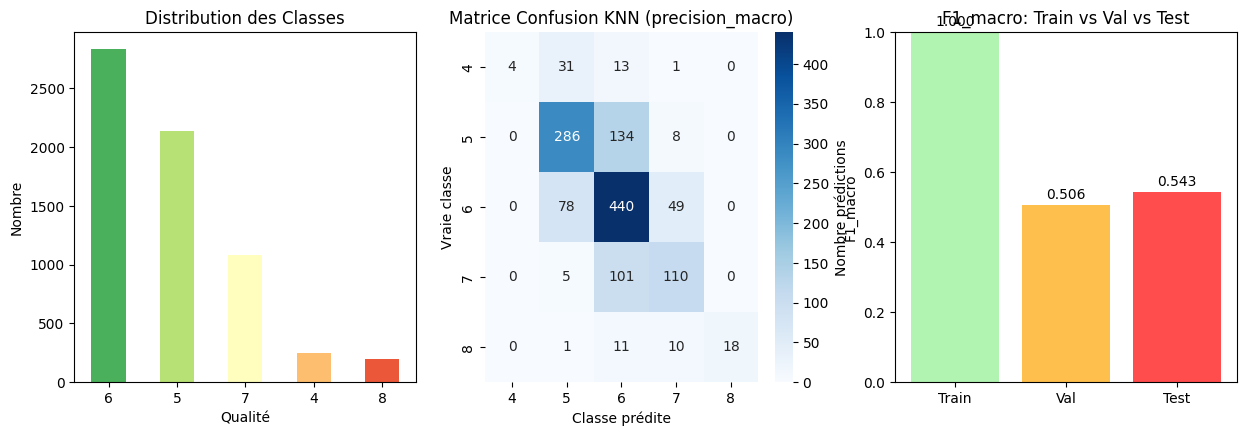

In [ ]:
# # visualisation matrice de confusion KNN
# # 11. VISUALISATION DES RÉSULTATS
# print("\n=== VISUALISATION ===")

# # Configuration des graphiques
# plt.figure(figsize=(15, 10))

# # 1. Distribution des classes
# plt.subplot(2, 3, 1)
# colors = sns.color_palette("RdYlGn_r", n_colors=5)
# y.value_counts().plot(kind='bar', color=colors)
# plt.title('Distribution des Classes')
# plt.ylabel('Nombre')
# plt.xlabel('Qualité')
# plt.xticks(rotation=0)

# # 2. Matrice de confusion (heatmap)
# plt.subplot(2, 3, 2)
# labels = ['4','5','6','7','8']  # Vos labels
# sns.heatmap(cm_knn2, annot=True, fmt='d', cmap='Blues', 
#             xticklabels=labels, yticklabels=labels,
#             cbar_kws={'label': 'Nombre prédictions'})
# plt.title('Matrice Confusion KNN (precision_macro)')
# plt.ylabel('Vraie classe')
# plt.xlabel('Classe prédite')

# # 3. Comparaison Train vs Test vs Val
# plt.subplot(2, 3, 3)
# metrics = [f1_score(Y_train, best_knn_macro.predict(X_train), average='macro'),
#            f1_score(Y_val, best_knn_macro.predict(X_val), average='macro'),
#            f1_score(y_test, y_test_pred, average='macro')]
# labels = ['Train', 'Val', 'Test']
# colors = ['lightgreen', 'orange', 'red']
# bars = plt.bar(labels, metrics, color=colors, alpha=0.7)
# plt.title('F1_macro: Train vs Val vs Test')
# plt.ylabel('F1_macro')
# plt.ylim(0, 1)
# for bar, m in zip(bars, metrics):
#     plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
#              f'{m:.3f}', ha='center', va='bottom')


#### 3.4.2 KNN : 3 categories - Precision & Accuracy

In [113]:
# Model KNN
print("\n=== GRIDS SEARCH POUR HYPERPARAMÈTRES KNN -precision===")

pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])
# Définition des hyperparamètres à tester
param_grid_knn = {
    'knn__n_neighbors': [3,7, 11, 15, 20, 25, 30], # plus grand pour éviter l'overfitting 
    'knn__weights': ['uniform'],  # 'uniform' pour moins d'overfitting
    'knn__metric': ['euclidean', 'manhattan', 'minkowski', 'chebyshev']
}
# Configuration de la validation croisée 
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Grille de recherche
grid_search_knn = GridSearchCV(
    pipeline_knn, param_grid_knn, 
    scoring='precision_macro', cv=cv_strategy, 
    n_jobs=-1, verbose=1, error_score="raise"
)


# Relance ton GridSearch dessus
grid_search_knn.fit(X2_train, Y2_train)

# Meilleurs hyperparamètres
print("\nMeilleurs hyperparamètres trouvés pour KNN:",grid_search_knn.best_params_)

# Meilleur score
print(f"Meilleur score de validation pour KNN: {grid_search_knn.best_score_:.2%}")

best_knn = grid_search_knn.best_estimator_
print(f"Meilleur best model KNN: {best_knn}")


# Prédictions
y2_train_pred = best_knn.predict(X2_train)
y2_val_pred = best_knn.predict(X2_val)
y2_test_pred = best_knn.predict(x2_test)

# Métriques train
print("\n=== MÉTRIQUES TRAIN KNN - PRECISION ===")
print(f"✅Accuracy train: {accuracy_score(Y2_train, y2_train_pred):.2%}")
print(f"✅Precision_macro train: {precision_score(Y2_train, y2_train_pred, average='macro'):.2%}")
print(f"✅Recall_macro train: {recall_score(Y2_train, y2_train_pred, average='macro'):.2%}")
print(f"✅F1_macro train: {f1_score(Y2_train, y2_train_pred, average='macro'):.2%}")
print(f"✅Val Precision: {precision_score(Y2_val, y2_val_pred, average='macro'):.3%}")


print("\n=== MÉTRIQUES TEST KNN - PRECISION ===")
print(f"✅Accuracy test: {accuracy_score(y2_test, y2_test_pred):.2%}")
print(f"✅Precision_macro test: {precision_score(y2_test, y2_test_pred, average='macro'):.2%}")
print(f"✅Recall_macro test: {recall_score(y2_test, y2_test_pred, average='macro'):.2%}")
print(f"✅F1_macro test: {f1_score(y2_test, y2_test_pred, average='macro'):.2%}")

print("\n=== RAPPORT DÉTAILLÉ TEST ===")
print(classification_report(y2_test, y2_test_pred))

cm_knn_3=confusion_matrix(y2_test, y2_test_pred)


=== GRIDS SEARCH POUR HYPERPARAMÈTRES KNN -precision===
Fitting 5 folds for each of 28 candidates, totalling 140 fits

Meilleurs hyperparamètres trouvés pour KNN: {'knn__metric': 'chebyshev', 'knn__n_neighbors': 11, 'knn__weights': 'uniform'}
Meilleur score de validation pour KNN: 57.05%
Meilleur best model KNN: Pipeline(steps=[('scaler', StandardScaler()),
                ('knn',
                 KNeighborsClassifier(metric='chebyshev', n_neighbors=11))])

=== MÉTRIQUES TRAIN KNN - PRECISION ===
✅Accuracy train: 65.88%
✅Precision_macro train: 65.30%
✅Recall_macro train: 64.19%
✅F1_macro train: 64.57%
✅Val Precision: 59.816%

=== MÉTRIQUES TEST KNN - PRECISION ===
✅Accuracy test: 56.30%
✅Precision_macro test: 55.40%
✅Recall_macro test: 54.59%
✅F1_macro test: 54.91%

=== RAPPORT DÉTAILLÉ TEST ===
              precision    recall  f1-score   support

           0       0.35      0.32      0.33       778
           1       0.81      0.77      0.79       992
           2       0.50      

In [115]:
# Model KNN
print("\n=== GRIDS SEARCH POUR HYPERPARAMÈTRES KNN - accuracy===")

pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])
# Définition des hyperparamètres à tester
param_grid_knn = {
    'knn__n_neighbors': [15, 20, 25, 30, 35, 40, 50], # plus grand pour éviter l'overfitting 
    'knn__weights': ['uniform'],  # 'uniform' pour moins d'overfitting
    'knn__metric': ['euclidean', 'manhattan', 'minkowski', 'chebyshev']
}
# Configuration de la validation croisée 
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Grille de recherche
grid_search_knn = GridSearchCV(
    pipeline_knn, param_grid_knn, 
    scoring='accuracy', cv=cv_strategy, 
    n_jobs=-1, verbose=1, error_score="raise"
)


# Relance ton GridSearch dessus
grid_search_knn.fit(X2_train, Y2_train)

# Meilleurs hyperparamètres
print("\nMeilleurs hyperparamètres trouvés pour KNN:",grid_search_knn.best_params_)

# Meilleur score
print(f"Meilleur score de validation pour KNN: {grid_search_knn.best_score_:.2%}")

best_knn = grid_search_knn.best_estimator_
print(f"Meilleur best model KNN: {best_knn}")


# Prédictions
y2_train_pred = best_knn.predict(X2_train)
y2_val_pred = best_knn.predict(X2_val)
y2_test_pred = best_knn.predict(x2_test)

# Métriques train
print("\n=== MÉTRIQUES TRAIN KNN - ACCURACY ===")
print(f"✅Accuracy train: {accuracy_score(Y2_train, y2_train_pred):.2%}")
print(f"✅Precision_macro train: {precision_score(Y2_train, y2_train_pred, average='macro'):.2%}")
print(f"✅Recall_macro train: {recall_score(Y2_train, y2_train_pred, average='macro'):.2%}")
print(f"✅F1_macro train: {f1_score(Y2_train, y2_train_pred, average='macro'):.2%}")
print(f"✅Accuracy: {accuracy_score(Y2_val, y2_val_pred):.3%}")


print("\n=== MÉTRIQUES TEST KNN - ACCURACY ===")
print(f"✅Accuracy test: {accuracy_score(y2_test, y2_test_pred):.2%}")
print(f"✅Precision_macro test: {precision_score(y2_test, y2_test_pred, average='macro'):.2%}")
print(f"✅Recall_macro test: {recall_score(y2_test, y2_test_pred, average='macro'):.2%}")
print(f"✅F1_macro test: {f1_score(y2_test, y2_test_pred, average='macro'):.2%}")

print("\n=== RAPPORT DÉTAILLÉ TEST ===")
print(classification_report(y2_test, y2_test_pred))

cm_knn_4=confusion_matrix(y2_test, y2_test_pred)


=== GRIDS SEARCH POUR HYPERPARAMÈTRES KNN - accuracy===
Fitting 5 folds for each of 28 candidates, totalling 140 fits

Meilleurs hyperparamètres trouvés pour KNN: {'knn__metric': 'chebyshev', 'knn__n_neighbors': 50, 'knn__weights': 'uniform'}
Meilleur score de validation pour KNN: 60.02%
Meilleur best model KNN: Pipeline(steps=[('scaler', StandardScaler()),
                ('knn',
                 KNeighborsClassifier(metric='chebyshev', n_neighbors=50))])

=== MÉTRIQUES TRAIN KNN - ACCURACY ===
✅Accuracy train: 62.24%
✅Precision_macro train: 61.02%
✅Recall_macro train: 58.05%
✅F1_macro train: 56.76%
✅Accuracy: 60.788%

=== MÉTRIQUES TEST KNN - ACCURACY ===
✅Accuracy test: 60.86%
✅Precision_macro test: 57.50%
✅Recall_macro test: 56.45%
✅F1_macro test: 54.53%

=== RAPPORT DÉTAILLÉ TEST ===
              precision    recall  f1-score   support

           0       0.38      0.14      0.21       778
           1       0.81      0.80      0.81       992
           2       0.53      0.75   

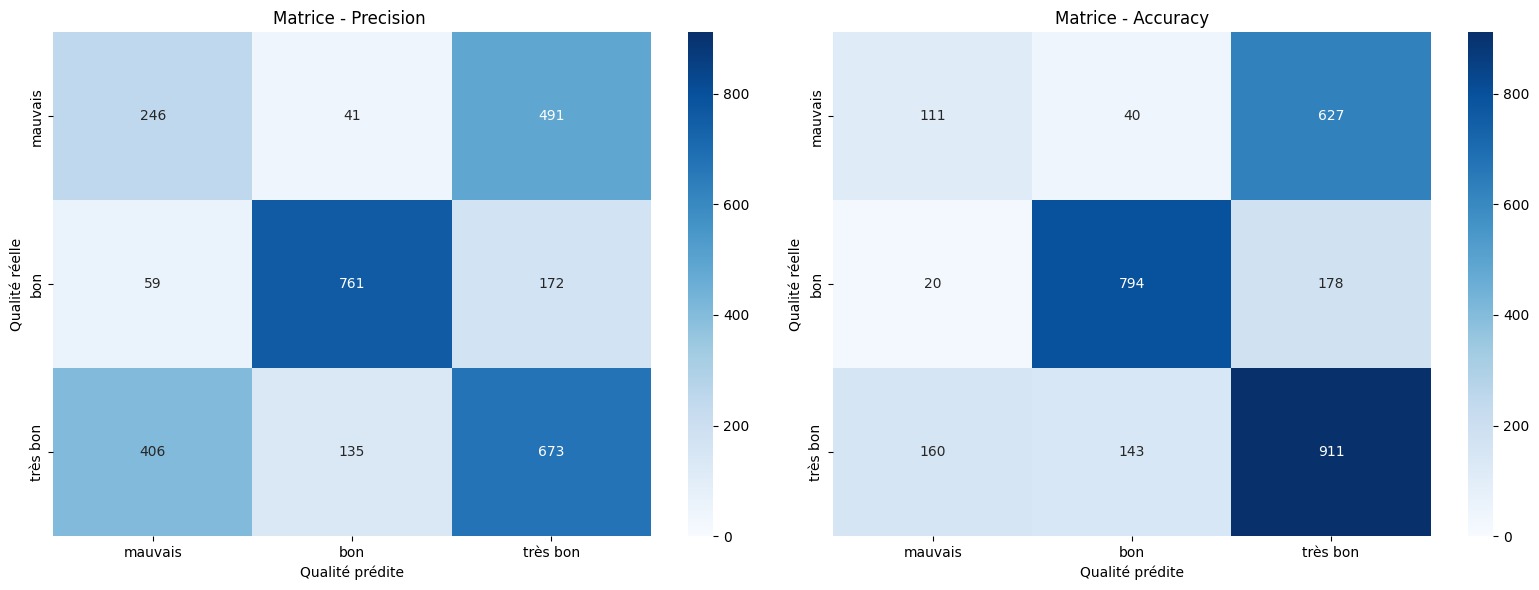

In [116]:
# Visualisation de la matrice de confusion
vmax = max(cm_knn_3.max(), cm_knn_4.max())
labels = ['mauvais', 'bon', 'très bon']  
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_knn_3, annot=True, fmt='d', cmap='Blues', vmin=0, vmax=vmax,
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Matrice - Precision ')
axes[0].set_xlabel('Qualité prédite')
axes[0].set_ylabel('Qualité réelle')

sns.heatmap(cm_knn_4, annot=True, fmt='d', cmap='Blues', vmin=0, vmax=vmax,
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Matrice - Accuracy')
axes[1].set_xlabel('Qualité prédite')
axes[1].set_ylabel('Qualité réelle')

plt.tight_layout()
plt.show()

### 4 Pipeline Preprocessing et Grid search - XG BOOST


#### 4.1 XG BOOST - 7 catgérories - F1_Macro & Precision

In [ ]:
# from xgboost import XGBClassifier
# print("\n🥇 XGBOOST - f1_macro")

# pipeline_xgb_f1 = Pipeline([
#     ('scaler', StandardScaler()),
#     ('xgb', XGBClassifier(
#         random_state=42,
#         eval_metric='mlogloss'
#     ))
# ])

# param_grid_xgb_f1 = {
#     'xgb__n_estimators': [100,200],
#     'xgb__max_depth': [3,4,5],
#     'xgb__learning_rate': [0.05,0.12,0.15],
#     'xgb__subsample': [0.8],
#     'xgb__colsample_bytree': [0.6,0.8],
#     'xgb__reg_alpha': [0.1, 0.5],        # L1 régularisation
#     'xgb__reg_lambda': [1, 1.5],         # L2 régularisation
#     'xgb__scale_pos_weight': [2, 3]      # ⚠️ CLÉ imbalanced
# }

# cv_5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# grid_xgb_f1 = GridSearchCV(
#     estimator=pipeline_xgb_f1,
#     param_grid=param_grid_xgb_f1,
#     scoring='f1_macro',
#     cv=cv_5,
#     n_jobs=-1,
#     verbose=1
# )


# # AVANT fit()
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# Y_train_enc = le.fit_transform(Y_train)
# Y_val_enc = le.transform(Y_val)
# y_test_enc = le.transform(y_test)  # x_test → y_test


# grid_xgb_f1.fit(X_train, Y_train_enc)  # Encoded !

# y_train_xgb = le.inverse_transform(grid_xgb_f1.best_estimator_.predict(X_train))
# y_val_xgb = le.inverse_transform(grid_xgb_f1.best_estimator_.predict(X_val))
# y_test_xgb = le.inverse_transform(grid_xgb_f1.best_estimator_.predict(x_test))

# print("=== XGBOOST f1_macro ===")
# print(f"Accuracy train: {accuracy_score(Y_train, y_train_xgb):.2%}")
# print(f"F1_macro train: {f1_score(Y_train, y_train_xgb, average='macro'):.2%}")
# print(f"✅ Val F1: {f1_score(Y_val, y_val_xgb, average='macro'):.3%}")
# print(f"Accuracy test: {accuracy_score(y_test, y_test_xgb):.2%}")
# print(f"F1_macro test: {f1_score(y_test, y_test_xgb, average='macro'):.2%}")
# print("Params:", grid_xgb_f1.best_params_)


🥇 XGBOOST - f1_macro
Fitting 5 folds for each of 288 candidates, totalling 1440 fits


c:\Users\alexa\Documents\IA_Alyra\IA_Alyra\Semaine 5 - ML\Code Live ML Partie 2\Training_ML_AM\.venv_clean\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:25:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBOOST f1_macro ===
Accuracy train: 63.16%
F1_macro train: 45.49%
✅ Val F1: 31.457%
Accuracy test: 53.29%
F1_macro test: 32.52%
Params: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.15, 'xgb__max_depth': 3, 'xgb__n_estimators': 100, 'xgb__reg_alpha': 0.5, 'xgb__reg_lambda': 1, 'xgb__scale_pos_weight': 2, 'xgb__subsample': 0.8}


In [ ]:
print("\n🥇 XGBOOST precision MAcro")

pipeline_xgb_pre = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(
        random_state=42,
        eval_metric='mlogloss'
    ))
])

param_grid_xgb_pre = {
    'xgb__n_estimators': [300],
    'xgb__max_depth': [6],
    'xgb__learning_rate': [0.05],
    'xgb__subsample': [0.8],
    'xgb__colsample_bytree': [0.8]
}

cv_5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_xgb_pre = GridSearchCV(
    estimator=pipeline_xgb_pre,
    param_grid=param_grid_xgb_pre,
    scoring='precision_macro',
    cv=cv_5,
    n_jobs=-1,
    verbose=1
)

grid_xgb_pre.fit(X_train, Y_train)

y_train_xgb2 = grid_xgb_pre.best_estimator_.predict(X_train)
y_val_xgb2 = grid_xgb_pre.best_estimator_.predict(X_val)
y_test_xgb2 = grid_xgb_pre.best_estimator_.predict(x_test)

print("=== XGBOOST f1_macro ===")
print(f"Accuracy train: {accuracy_score(Y_train, y_train_xgb2):.2%}")
print(f"F1_macro train: {f1_score(Y_train, y_train_xgb2, average='macro'):.2%}")
print(f"✅ Val F1: {f1_score(Y_val, y_val_xgb, average='macro'):.3%}")
print(f"Accuracy test: {accuracy_score(y_test, y_test_xgb2):.2%}")
print(f"F1_macro test: {f1_score(y_test, y_test_xgb2, average='macro'):.2%}")
print("Params:", grid_xgb_pre.best_params_)

#### 4.2 XGBoost - 3 categories - Accuracy & Precision

In [120]:
from xgboost import XGBClassifier
print("\n🥇 XGBOOST - accuracy")

pipeline_xgb_f1 = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(
        random_state=42,
        eval_metric='mlogloss'
    ))
])

param_grid_xgb_f1 = {
    'xgb__n_estimators': [200,300,500],
    'xgb__max_depth': [3,5,15],
    'xgb__learning_rate': [0.05,0.12,0.15],
    'xgb__subsample': [0.8],
    'xgb__colsample_bytree': [0.6,0.8],
    'xgb__reg_alpha': [0.1, 0.5],        # L1 régularisation
    'xgb__reg_lambda': [1, 1.5]         # L2 régularisation
}

cv_5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_xgb_f1 = GridSearchCV(
    estimator=pipeline_xgb_f1,
    param_grid=param_grid_xgb_f1,
    scoring='accuracy',
    cv=cv_5,
    n_jobs=-1,
    verbose=1
)


# AVANT fit()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Y2_train_enc = le.fit_transform(Y2_train)
Y2_val_enc = le.transform(Y2_val)
y2_test_enc = le.transform(y2_test)  # x_test → y_test


grid_xgb_f1.fit(X2_train, Y2_train_enc)  # Encoded !

y2_train_xgb = le.inverse_transform(grid_xgb_f1.best_estimator_.predict(X2_train))
y2_val_xgb = le.inverse_transform(grid_xgb_f1.best_estimator_.predict(X2_val))
y2_test_xgb = le.inverse_transform(grid_xgb_f1.best_estimator_.predict(x2_test))

print("=== XGBOOST accuracy ===")
print(f"Accuracy train: {accuracy_score(Y2_train, y2_train_xgb):.2%}")
print(f"F1_macro train: {f1_score(Y2_train, y2_train_xgb, average='macro'):.2%}")
print(f"✅ Val accuracy: {accuracy_score(Y2_val, y2_val_xgb):.3%}")
print(f"Accuracy test: {accuracy_score(y2_test, y2_test_xgb):.2%}")
print(f"F1_macro test: {f1_score(y2_test, y2_test_xgb, average='macro'):.2%}")
print("Params:", grid_xgb_f1.best_params_)

# matrice de confusion
cm_xgb_3=confusion_matrix(y2_test, y2_test_pred)


🥇 XGBOOST - accuracy
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
=== XGBOOST accuracy ===
Accuracy train: 63.05%
F1_macro train: 51.64%
✅ Val accuracy: 62.338%
Accuracy test: 62.40%
F1_macro test: 50.29%
Params: {'xgb__colsample_bytree': 0.6, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 3, 'xgb__n_estimators': 200, 'xgb__reg_alpha': 0.5, 'xgb__reg_lambda': 1, 'xgb__subsample': 0.8}


In [ ]:
print("\n🥇 XGBOOST precision MAcro")

pipeline_xgb_pre = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(
        random_state=42,
        eval_metric='mlogloss'
    ))
])

param_grid_xgb_pre = {
    'xgb__n_estimators': [200,300,500],
    'xgb__max_depth': [3,5,15],
    'xgb__learning_rate': [0.05,0.12,0.15],
    'xgb__subsample': [0.8],
    'xgb__colsample_bytree': [0.6,0.8],
    'xgb__reg_alpha': [0.1, 0.5],        # L1 régularisation
    'xgb__reg_lambda': [1, 1.5]         # L2 régularisation
}

cv_5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_xgb_pre = GridSearchCV(
    estimator=pipeline_xgb_pre,
    param_grid=param_grid_xgb_pre,
    scoring='precision_macro',
    cv=cv_5,
    n_jobs=-1,
    verbose=1
)

grid_xgb_pre.fit(X2_train, Y2_train)

y2_train_xgb2 = grid_xgb_pre.best_estimator_.predict(X2_train)
y2_val_xgb2 = grid_xgb_pre.best_estimator_.predict(X2_val)
y2_test_xgb2 = grid_xgb_pre.best_estimator_.predict(x2_test)

print("=== XGBOOST f1_macro ===")
print(f"Accuracy train: {accuracy_score(Y2_train, y2_train_xgb2):.2%}")
print(f"F1_macro train: {f1_score(Y2_train, y2_train_xgb2, average='macro'):.2%}")
print(f"✅ Val F1: {f1_score(Y2_val, y2_val_xgb, average='macro'):.3%}")
print(f"Accuracy test: {accuracy_score(y2_test, y2_test_xgb2):.2%}")
print(f"F1_macro test: {f1_score(y2_test, y2_test_xgb2, average='macro'):.2%}")
print("Params:", grid_xgb_pre.best_params_)

# matrice de confusion
cm_xgb_4=confusion_matrix(y2_test, y2_test_pred)

In [ ]:
# Visualisation de la matrice de confusion
vmax = max(cm_xgb_3.max(), cm_xgb_4.max())
labels = ['mauvais', 'bon', 'très bon']  
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_xgb_3, annot=True, fmt='d', cmap='Blues', vmin=0, vmax=vmax,
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Matrice - Precision ')
axes[0].set_xlabel('Qualité prédite')
axes[0].set_ylabel('Qualité réelle')

sns.heatmap(cm_xgb_4, annot=True, fmt='d', cmap='Blues', vmin=0, vmax=vmax,
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Matrice - Accuracy')
axes[1].set_xlabel('Qualité prédite')
axes[1].set_ylabel('Qualité réelle')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import f1_score
import pandas as pd

# 🏆 Vos modèles précision_macro pour 3 catégories 
precision_macro_models = {
    'Random Forest_3categ_prec_macro': best_rf2,
    'Gradient Boost_prec_macro': best_gbt2,
    'KNN_prec_macro': best_knn_macro
}

# CALCUL AUTO
f1_val_results = {}
for name, model in precision_macro_models.items():
    y_val_pred = model.predict(X_val)
    f1_val_results[name] = f1_score(Y_val, y_val_pred, average='macro')

# 🥇 DataFrame SIMPLE (pas de style)
df_winner = pd.DataFrame([
    {'Modèle': name, 'F1_macro_Val': f'{score:.3%}'}
    for name, score in sorted(f1_val_results.items(), key=lambda x: x[1], reverse=True)
])

print("🏆 **MEILLEUR F1_macro VALIDATION** (précision_macro)")
print(df_winner.to_string(index=False))

# TOP 1
best_model = df_winner.iloc[0]['Modèle']
best_score = max(f1_val_results.values())
print(f"\n🥇 **{best_model}** : {best_score:.3%}")
print(f"🥈 2ème : {sorted(f1_val_results.values(), reverse=True)[1]:.3%}")

🏆 **MEILLEUR F1_macro VALIDATION** (précision_macro)
              Modèle F1_macro_Val
     KNN2_prec_macro      50.572%
      RF2_prec_macro      50.124%
     GBT2_prec_macro      48.012%
AdaBoost2_prec_macro      33.745%

🥇 **KNN2_prec_macro** : 50.572%
🥈 2ème : 50.124%


#### En conclusion : le modele KNN est ok pour scoring='precision_macro'